# Tech Challenge - Fase 1
## Sistema inteligente de suporte ao diagnostico

**Tarefa principal:** classificacao de biopsias mamarias em **maligno** ou **benigno**
a partir de dados tabulares, usando algoritmos de aprendizado de maquina.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) - 569 biopsias por puncao aspirativa
por agulha fina (PAAF), 30 atributos morfometricos extraidos digitalmente da imagem do
nucleo celular.

**Contexto clinico.** Um hospital universitario recebe mais exames do que a equipe de
patologia consegue laudar no mesmo dia. A proposta nao e substituir o patologista: e
**ordenar a fila** de forma que os casos com alta suspeita de malignidade sejam vistos
primeiro, e sinalizar explicitamente os casos de incerteza. A palavra final sobre o
diagnostico continua sendo, sempre, do medico responsavel.

> Este notebook e uma demonstracao narrada. O pipeline completo, automatizado e
> testado, vive em `scripts/run_pipeline.py` e no pacote `src/medai/`.


## 0. Preparacao do ambiente

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import Image, display

from medai import data as data_mod
from medai import eda, evaluate, interpret, models
from medai.config import ensure_dirs, set_global_seed, RANDOM_STATE
from medai.preprocessing import (
    build_preprocessor, correlation_analysis, inject_missing, split_train_val_test,
)

ensure_dirs()
set_global_seed(RANDOM_STATE)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
print("ambiente pronto | semente =", RANDOM_STATE)

ambiente pronto | semente = 42


## 1. Carga e auditoria da base

Antes de qualquer modelagem, auditamos a base: dimensoes, tipos, valores ausentes,
duplicatas, colunas constantes e **zeros biologicamente impossiveis** (raio ou area
iguais a zero seriam ausencia disfarcada de valor, um problema comum em bases medicas).

In [2]:
df = data_mod.load_raw()
print("dimensoes:", df.shape)
df.head()

20:46:25 | INFO    | lendo dataset local: C:\Users\andre\.gemini\antigravity\scratch\etapa1\data\raw\breast_cancer_wisconsin.csv


20:46:25 | INFO    | dataset carregado: 569 linhas x 31 colunas


dimensoes: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
auditoria = data_mod.audit(df)
for chave, valor in auditoria.items():
    print(f"{chave:.<28} {valor}")

n_rows...................... 569
n_cols...................... 31
n_numeric................... 30
n_categorical............... 1
categorical_columns......... ['diagnosis']
missing_total............... 0
missing_by_column........... {}
duplicated_rows............. 0
duplicated_ids.............. None
constant_columns............ []
impossible_zeros............ {}
class_counts................ {'B': 357, 'M': 212}
class_balance_pct........... {'B': 62.74, 'M': 37.26}
imbalance_ratio............. 1.684


**Leitura.** A base esta limpa: nenhum valor ausente, nenhuma linha duplicada, nenhuma
coluna constante e nenhum zero impossivel. O desbalanceamento e leve (1,68:1 a favor
dos benignos) - nao chega a exigir reamostragem, mas **e suficiente para tornar a
acuracia uma metrica enganosa**: um modelo que responde sempre "benigno" ja acerta
62,7% dos casos sem detectar um unico cancer.

In [4]:
descritivas = data_mod.describe_numeric(df)
descritivas[["mean", "std", "min", "max", "skew", "cv"]].head(12)

,mean,std,min,max,skew,cv
radius_mean,14.1273,3.5240,6.9810,28.1100,0.9424,0.2494
texture_mean,19.2896,4.3010,9.7100,39.2800,0.6504,0.2230
perimeter_mean,91.9690,24.2990,43.7900,188.5000,0.9907,0.2642
area_mean,654.8891,351.9141,143.5000,2501.0000,1.6457,0.5374
smoothness_mean,0.0964,0.0141,0.0526,0.1634,0.4563,0.1460
compactness_mean,0.1043,0.0528,0.0194,0.3454,1.1901,0.5062
concavity_mean,0.0888,0.0797,0.0000,0.4268,1.4012,0.8978
concave_points_mean,0.0489,0.0388,0.0000,0.2012,1.1712,0.7932
symmetry_mean,0.1812,0.0274,0.1060,0.3040,0.7256,0.1513
fractal_dimension_mean,0.0628,0.0071,0.0500,0.0974,1.3045,0.1124


**Leitura.** As escalas sao radicalmente diferentes: `area_worst` chega a ~4.250
enquanto `fractal_dimension_se` fica na casa de 0,003 - mais de tres ordens de grandeza.
Varias variaveis tambem tem assimetria positiva forte (`skew` > 1). Isso ja define duas
decisoes de pre-processamento: **padronizar a escala** (obrigatorio para KNN, SVM e para
a regularizacao da regressao logistica) e **imputar pela mediana**, nao pela media.

## 2. Analise exploratoria

variaveis mais discriminantes: ['concave_points_worst', 'perimeter_worst', 'concave_points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean']


20:46:26 | INFO    | figura salva -> etapa1\reports\figures\01_balanceamento_classes.png


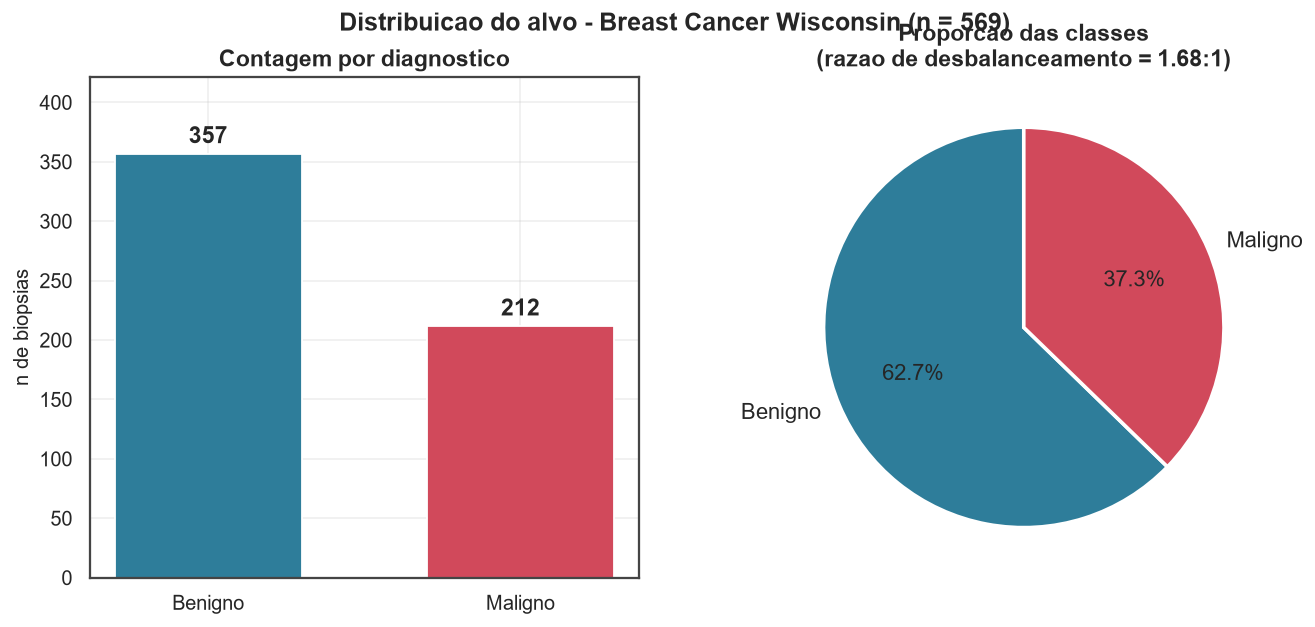

In [5]:
X, y = data_mod.split_features_target(df)
top_feats = eda.top_discriminative_features(df, y, k=9)
print("variaveis mais discriminantes:", top_feats)

display(Image(eda.plot_class_balance(df)))

20:46:30 | INFO    | figura salva -> etapa1\reports\figures\02_distribuicoes_por_classe.png


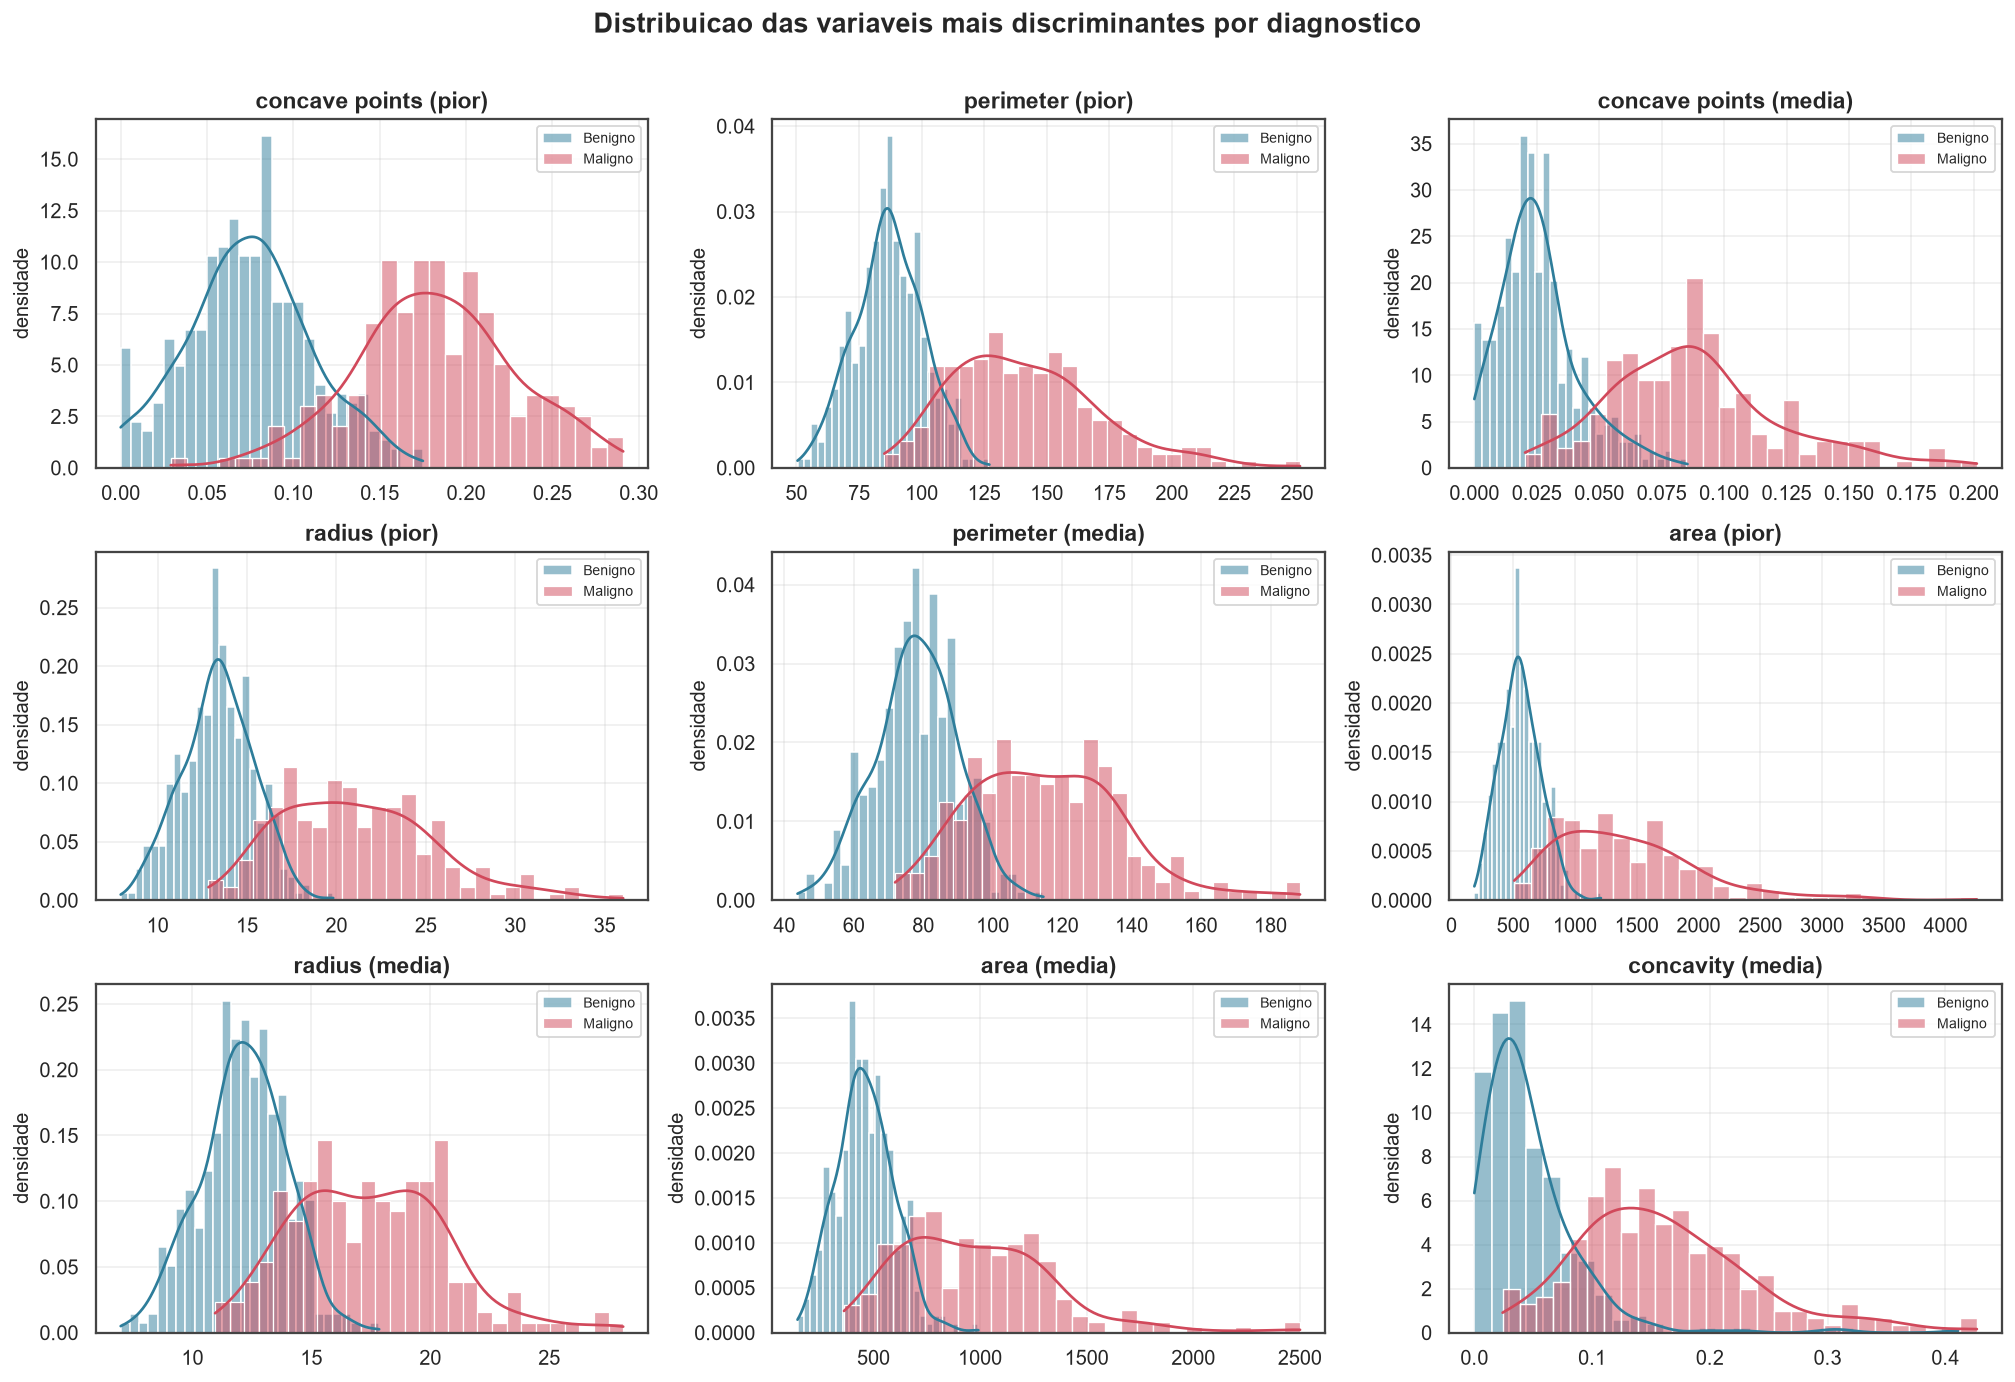

In [6]:
display(Image(eda.plot_distributions(df, top_feats)))

**Leitura.** Para as variaveis do grupo `worst` (media dos 3 maiores nucleos de cada
lamina) as duas distribuicoes praticamente nao se sobrepoem: tumores malignos tem
nucleos maiores, mais irregulares e com mais pontos concavos no contorno. Isso e
coerente com o criterio histopatologico de atipia nuclear - o modelo vai aprender algo
que o patologista ja usa, e nao um artefato do dataset.

20:46:32 | INFO    | figura salva -> etapa1\reports\figures\03_boxplots_por_classe.png


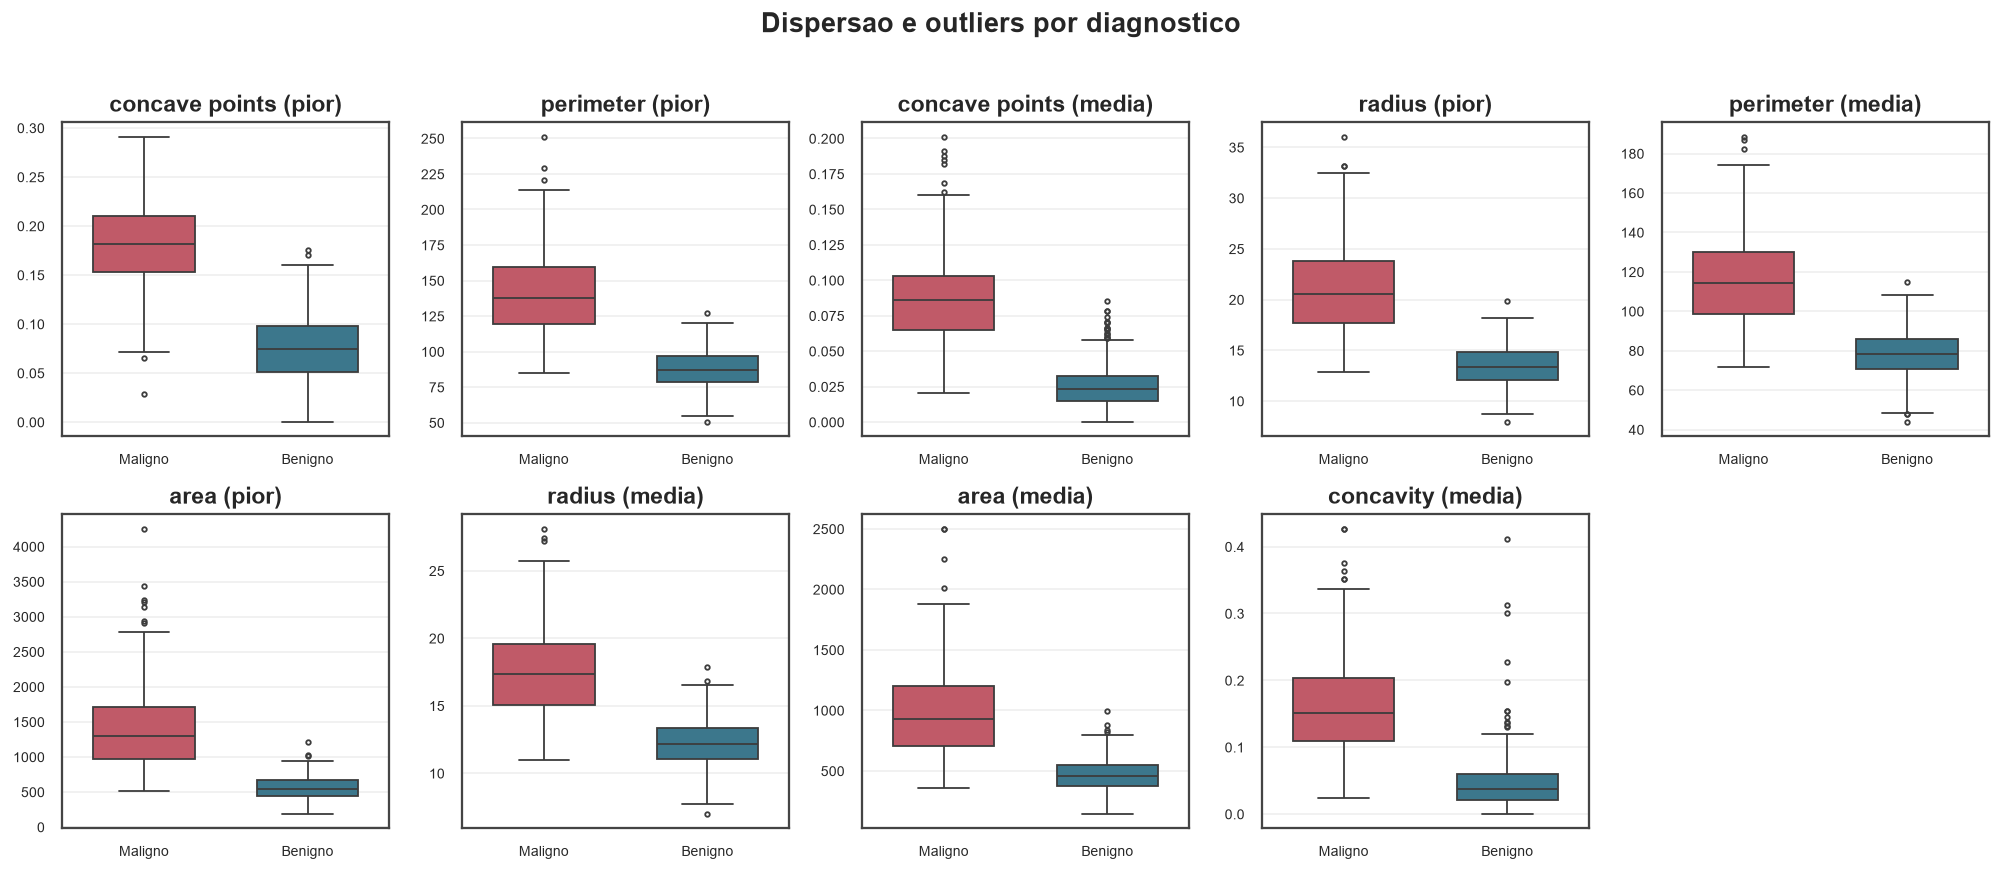

In [7]:
display(Image(eda.plot_boxplots(df, top_feats)))

20:46:34 | INFO    | figura salva -> etapa1\reports\figures\08_escala_e_assimetria.png


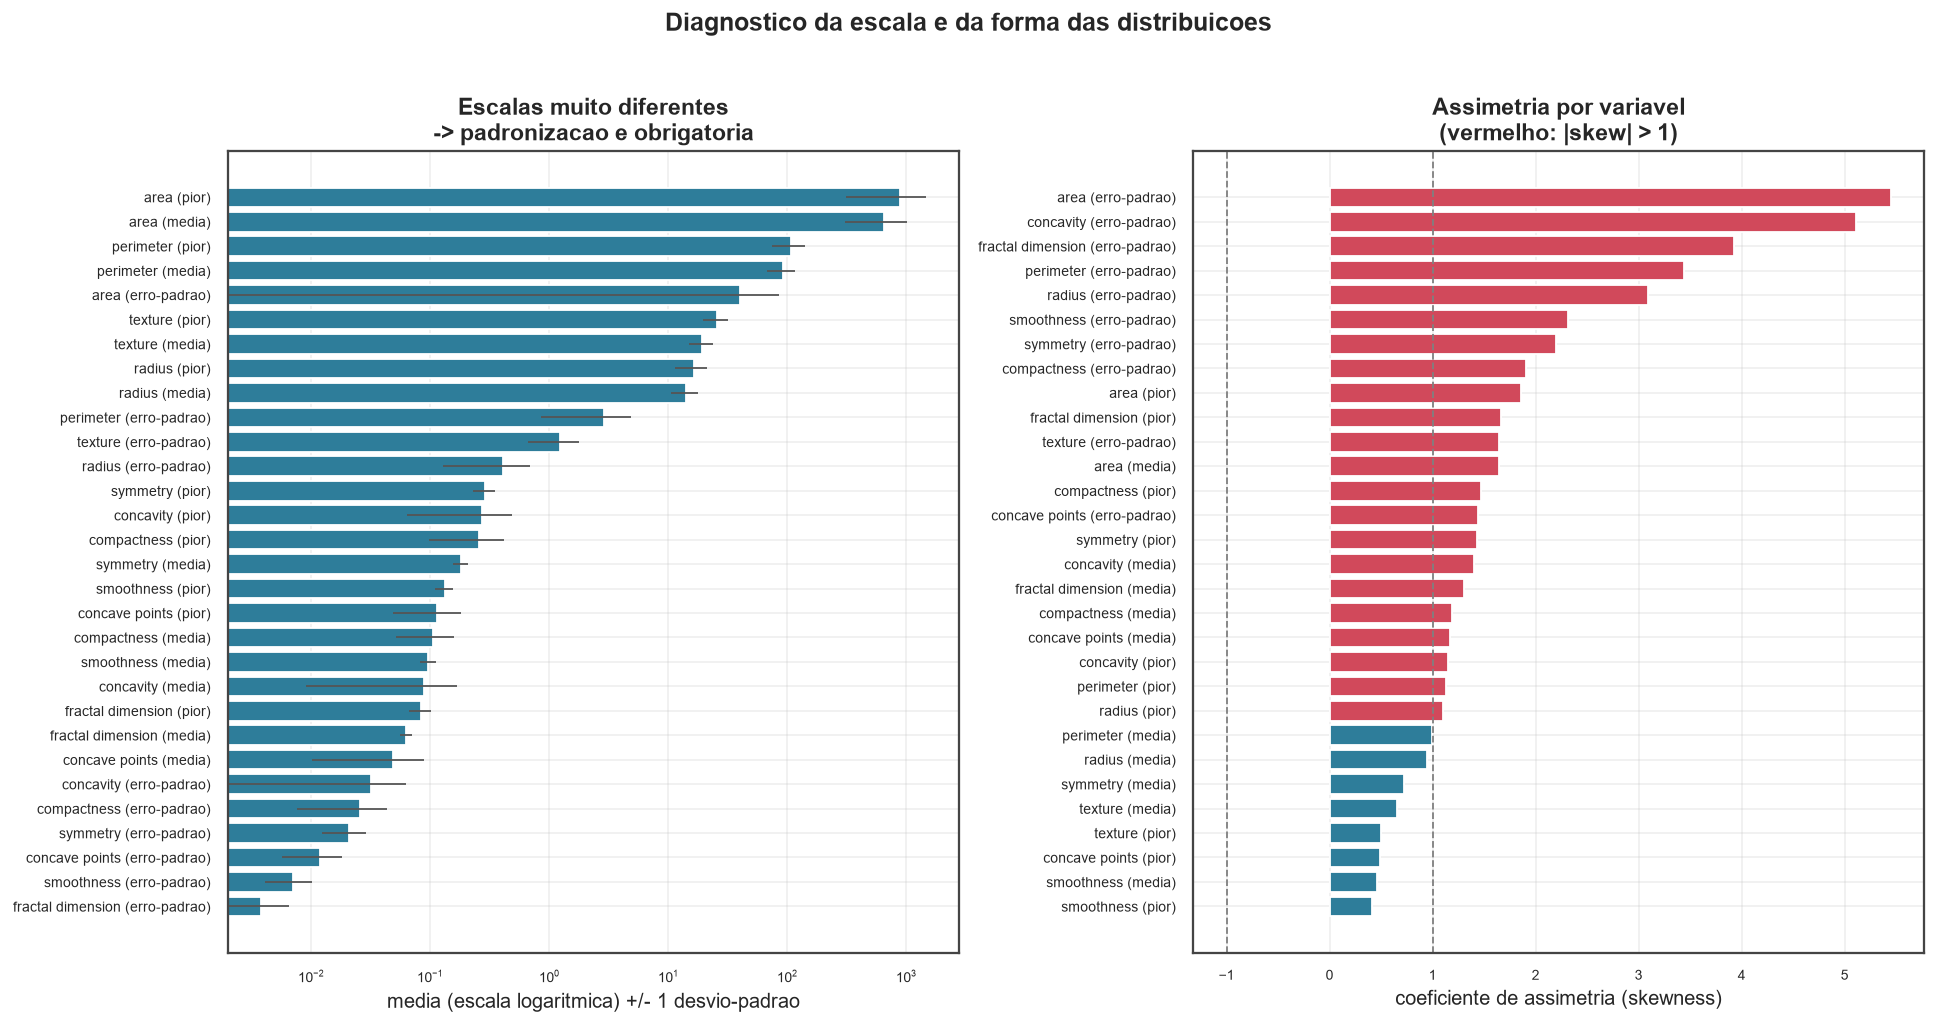

In [8]:
display(Image(eda.plot_scale_and_skew(df)))

20:46:34 | INFO    | figura salva -> etapa1\reports\figures\06_projecao_pca.png


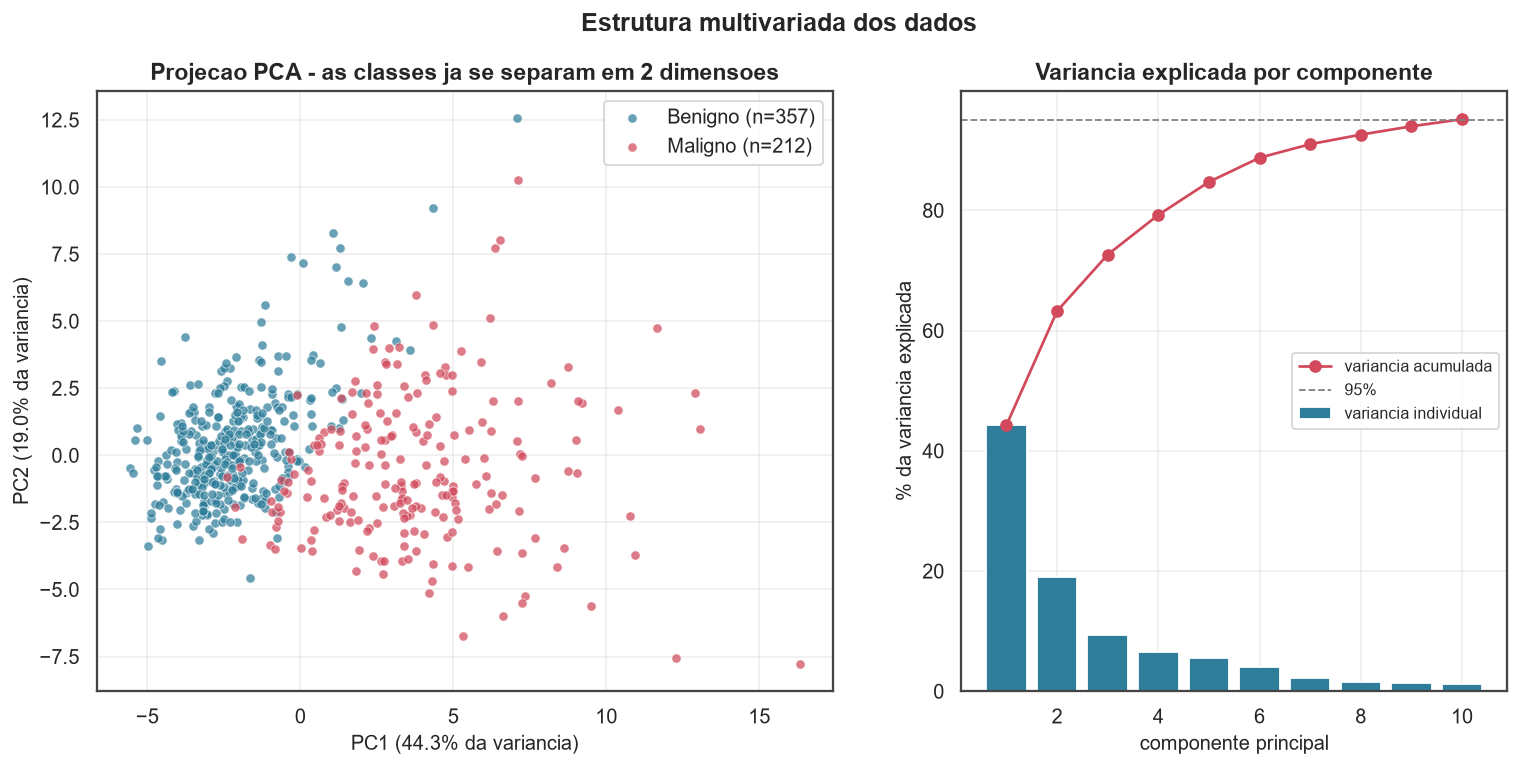

In [9]:
display(Image(eda.plot_pca_projection(df)))

**Leitura.** Duas componentes principais ja concentram ~63% da variancia e separam
visualmente as classes. Isso sinaliza que o problema e **quase linearmente separavel** -
uma expectativa importante: se um modelo complexo nao superar a regressao logistica por
uma margem relevante, devemos ficar com o modelo simples.

20:46:37 | INFO    | figura salva -> etapa1\reports\figures\07_dispersao_pareada.png


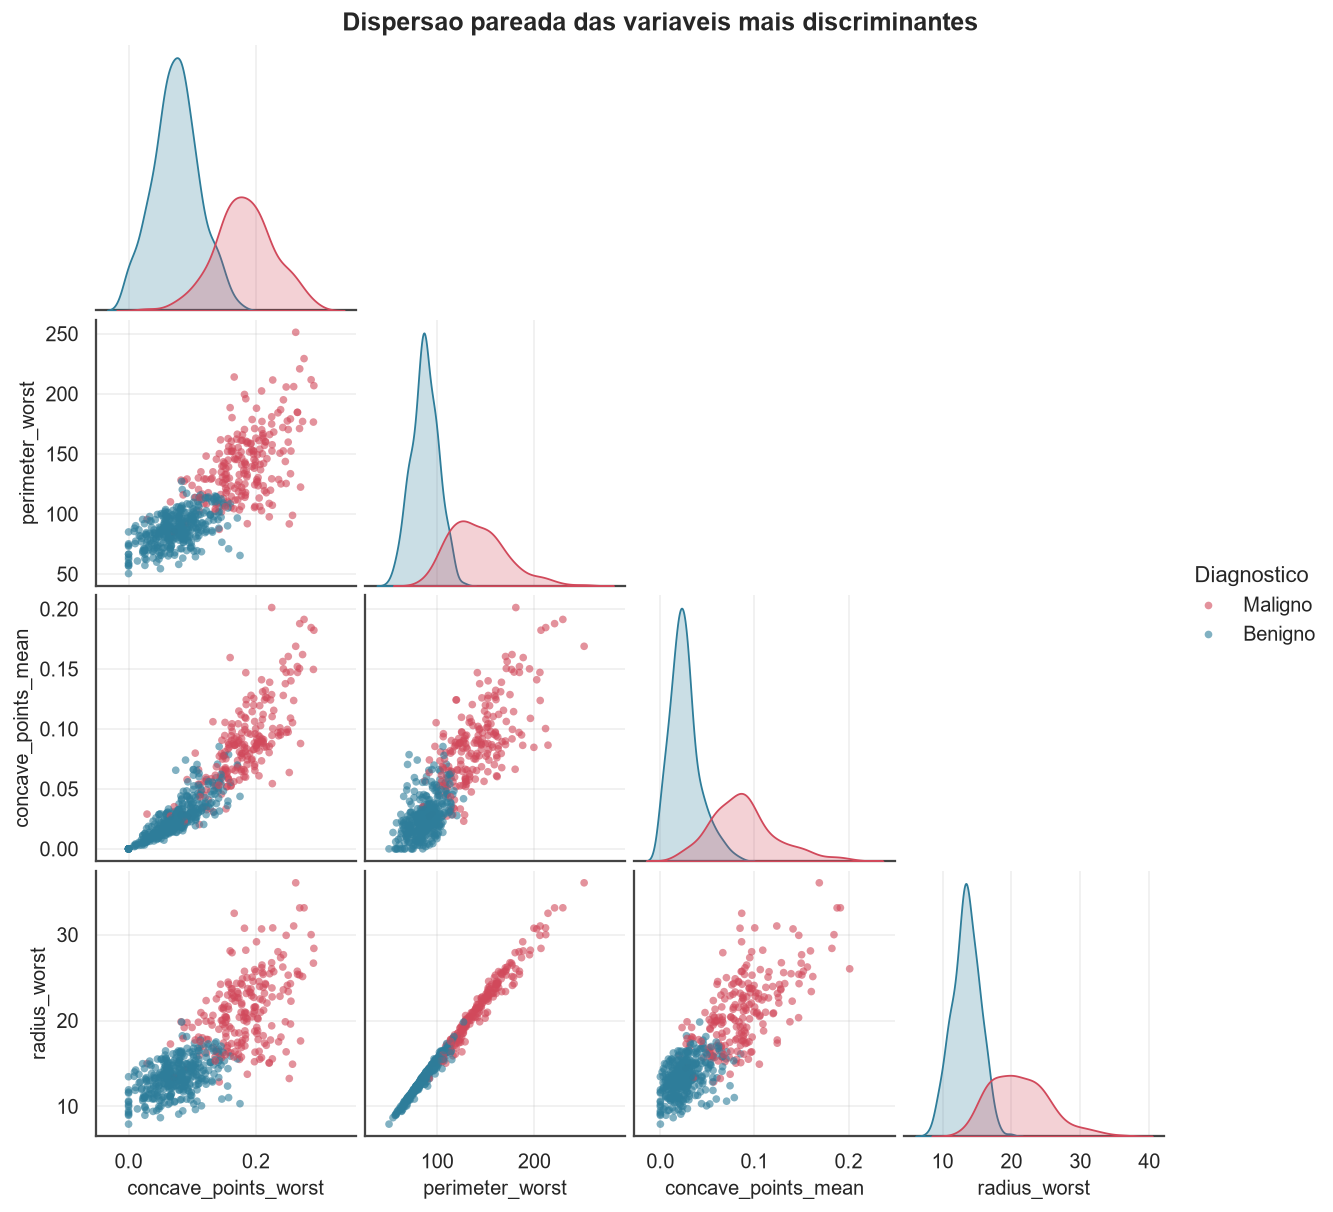

In [10]:
display(Image(eda.plot_pairwise(df, top_feats[:4])))

## 3. Analise de correlacao

Duas perguntas distintas: (a) quais variaveis se associam ao diagnostico e (b) quais
variaveis sao redundantes entre si (multicolinearidade).

20:46:37 | INFO    | correlacao: 21 par(es) com |r| >= 0.90 | 10 coluna(s) redundante(s)


20:46:38 | INFO    | figura salva -> etapa1\reports\figures\04_matriz_correlacao.png


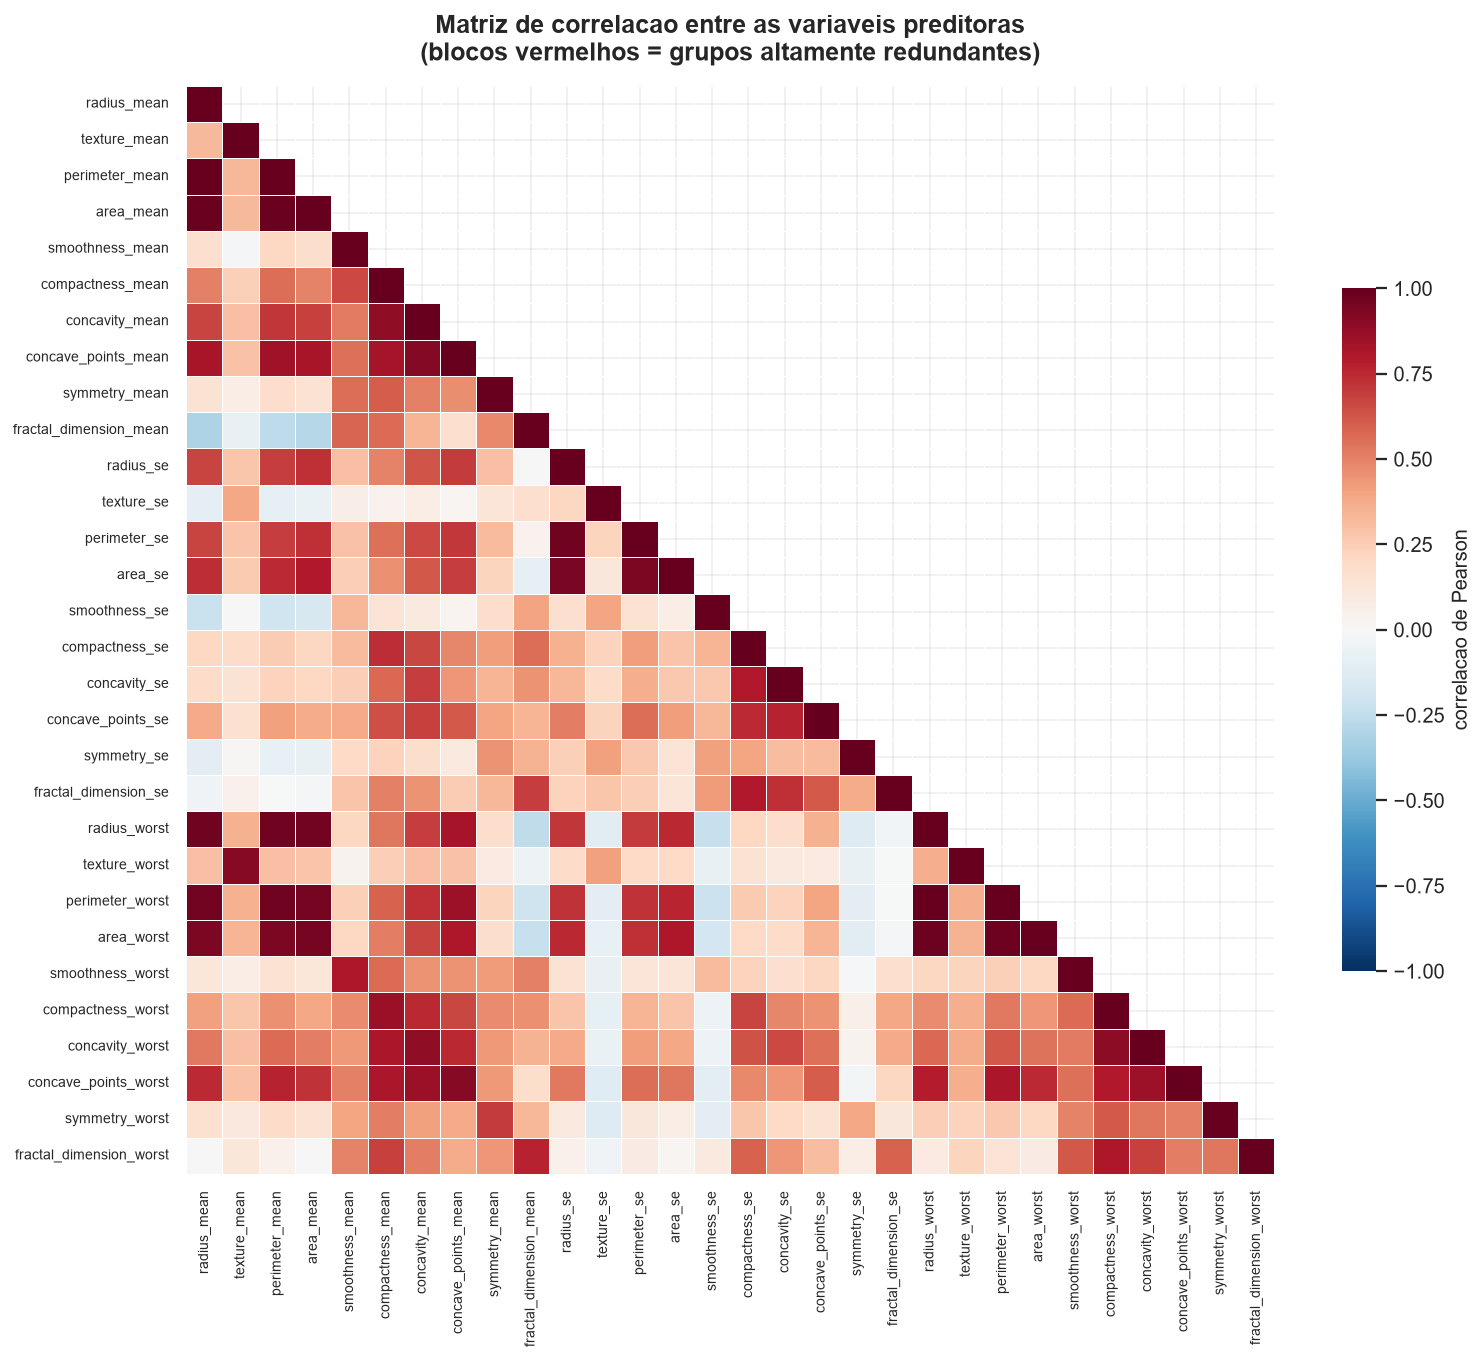

In [11]:
corr = correlation_analysis(X, y, threshold=0.90)
display(Image(eda.plot_correlation_heatmap(corr.matrix)))

In [12]:
print(f"pares com |r| >= 0,90: {len(corr.redundant_pairs)}")
display(corr.redundant_pairs.head(10))
print("\ncolunas redundantes sugeridas para descarte:")
print(corr.suggested_drop)

pares com |r| >= 0,90: 21


,feature_a,feature_b,correlacao
0,radius_mean,perimeter_mean,0.9979
1,radius_worst,perimeter_worst,0.9937
2,radius_mean,area_mean,0.9874
3,perimeter_mean,area_mean,0.9865
4,radius_worst,area_worst,0.9840
5,perimeter_worst,area_worst,0.9776
6,radius_se,perimeter_se,0.9728
7,perimeter_mean,perimeter_worst,0.9704
8,radius_mean,radius_worst,0.9695
9,perimeter_mean,radius_worst,0.9695



colunas redundantes sugeridas para descarte:
['area_mean', 'area_se', 'area_worst', 'concave_points_mean', 'concavity_mean', 'perimeter_mean', 'perimeter_se', 'radius_mean', 'radius_worst', 'texture_mean']


20:46:39 | INFO    | figura salva -> etapa1\reports\figures\05_correlacao_com_alvo.png


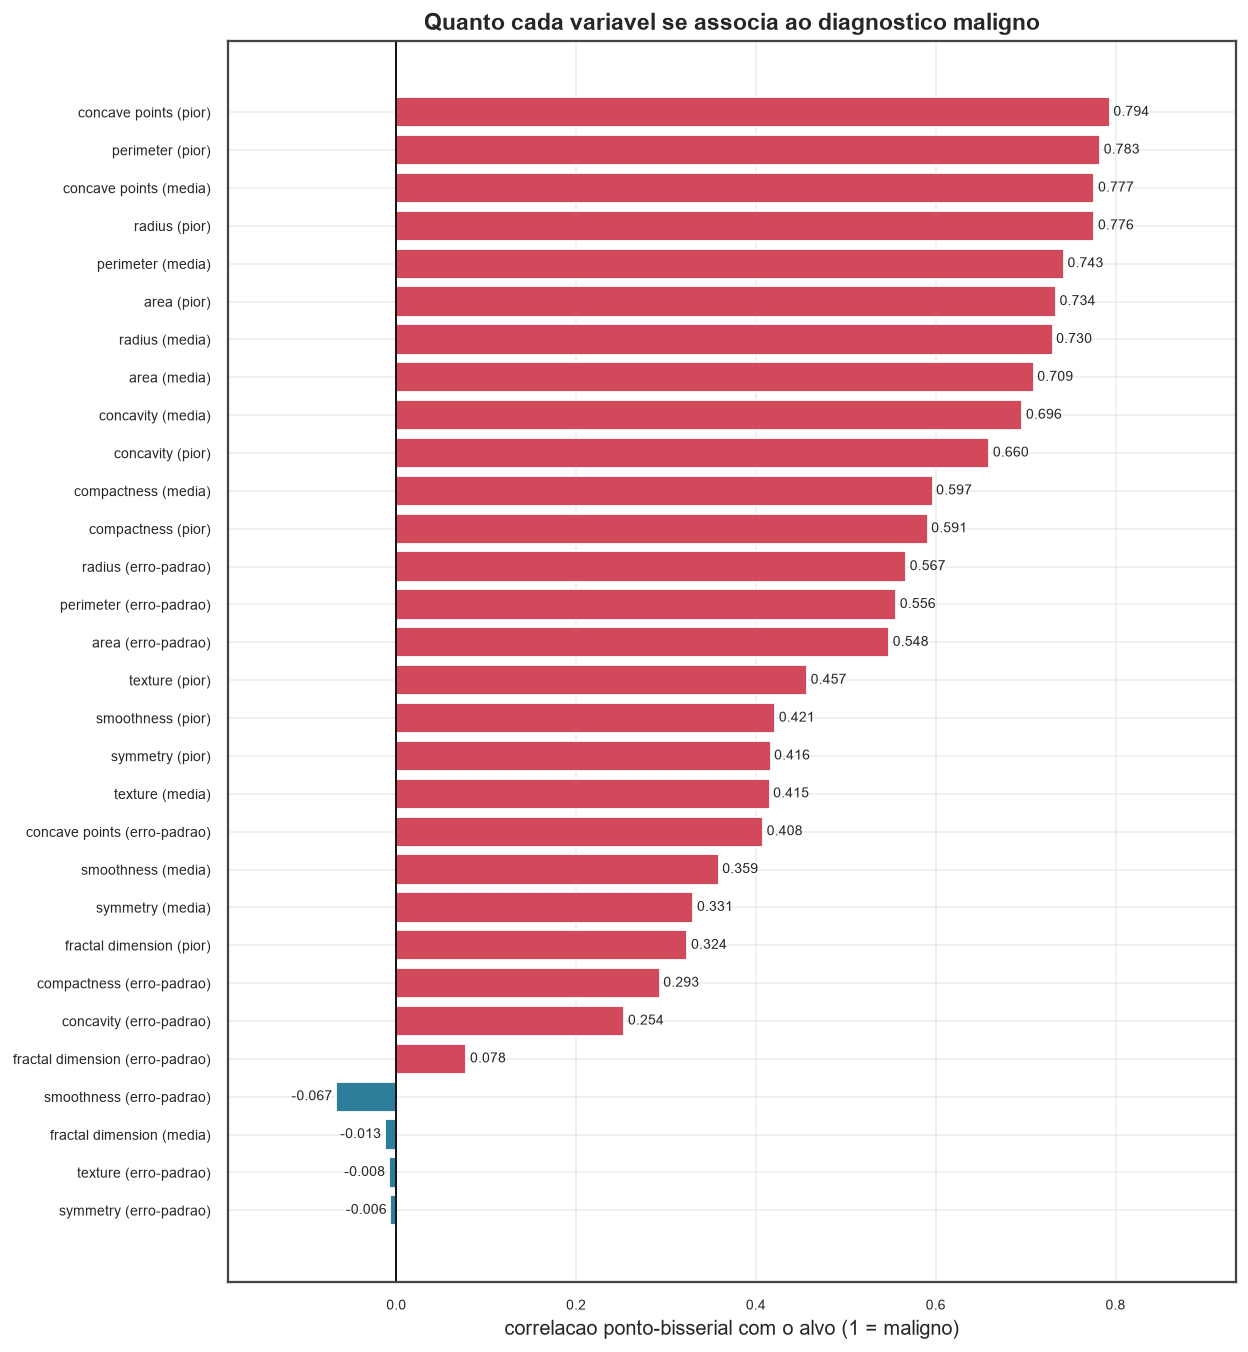

In [13]:
display(Image(eda.plot_target_correlation(corr.with_target)))

**Leitura.** Ha blocos de redundancia quase perfeita - `radius`, `perimeter` e `area`
medem a mesma geometria do nucleo (r > 0,98). Isso **nao prejudica** arvores, SVM ou
KNN, mas desestabiliza a interpretacao dos coeficientes da regressao logistica: o peso
de uma variavel pode "vazar" para a gemea. Por isso a interpretacao final se apoia em
permutacao e SHAP, e nao apenas nos coeficientes. Optamos por **manter as 30 variaveis**
e controlar a colinearidade via regularizacao L2, preservando a informacao.

## 4. Separacao treino / validacao / teste

Tres particoes estratificadas (60/20/20), com papeis rigidamente separados:

| particao | papel |
|---|---|
| **treino** (60%) | ajuste dos modelos e busca de hiperparametros por validacao cruzada |
| **validacao** (20%) | escolha do campeao e calibracao do limiar clinico |
| **teste** (20%) | aberto **uma unica vez**, ao final, para a estimativa honesta |

In [14]:
split = split_train_val_test(X, y)
split.summary()

20:46:39 | INFO    | split estratificado -> treino=341 | validacao=114 | teste=114


,n,pct_do_total,benignos,malignos,prevalencia_maligno_%
particao,,,,,
treino,341,59.9,214,127,37.24
validacao,114,20.0,71,43,37.72
teste,114,20.0,72,42,36.84


## 5. Pipeline de pre-processamento

Todo o pre-processamento vive dentro de um `sklearn.Pipeline`. Isso e o que impede
**vazamento de dados**: a media e o desvio usados na padronizacao sao aprendidos so no
treino e depois aplicados a validacao e ao teste.

O `ColumnTransformer` tem dois ramos automaticos: numerico (mediana + z-score) e
categorico (moda + one-hot com `handle_unknown="ignore"`). No WDBC as 30 preditoras sao
numericas, entao o ramo categorico fica vazio - mas ele e mantido porque o mesmo
pipeline atende outras bases clinicas (sexo, unidade, tipo de exame) sem alteracao de
codigo.

In [15]:
pre = build_preprocessor(split.X_train)
pre.fit(split.X_train)
X_train_proc = pre.transform(split.X_train)
print("saida do pre-processador:", np.asarray(X_train_proc).shape)
pd.DataFrame(np.asarray(X_train_proc), columns=pre.get_feature_names_out()).iloc[:4, :6].round(3)

20:46:39 | INFO    | preprocessador: 30 coluna(s) numerica(s) [escala=standard], 0 categorica(s)


saida do pre-processador: (341, 30)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean
0,0.194,0.868,0.331,0.033,0.614,1.784
1,-1.660,-0.594,-1.630,-1.273,-0.677,-0.821
2,-0.819,0.099,-0.815,-0.758,0.684,-0.664
3,-0.176,-1.949,-0.172,-0.279,2.347,0.030


In [16]:
# Prova de que o ramo categorico funciona e de que a imputacao cobre valores ausentes.
demo = pd.DataFrame({
    "idade":   [45.0, 62.0, np.nan, 51.0],
    "sexo":    ["F", "F", "M", None],
    "unidade": ["HC", "HC", "UPA", "UPA"],
})
pre_demo = build_preprocessor(demo)
saida = pd.DataFrame(np.asarray(pre_demo.fit_transform(demo)),
                     columns=pre_demo.get_feature_names_out())
print("entrada com ausentes e categoricas -> saida numerica sem NaN:")
saida.round(3)

20:46:39 | INFO    | preprocessador: 1 coluna(s) numerica(s) [escala=standard], 2 categorica(s)


entrada com ausentes e categoricas -> saida numerica sem NaN:


,idade,sexo_F,sexo_M,unidade_HC,unidade_UPA
0,-1.181,1.0,0.0,1.0,0.0
1,1.588,1.0,0.0,1.0,0.0
2,-0.204,0.0,1.0,0.0,1.0
3,-0.204,1.0,0.0,0.0,1.0


## 6. Modelagem

Seis familias de modelos, cada uma com uma grade de hiperparametros buscada por
`GridSearchCV` com `StratifiedKFold` de 5 dobras **apenas no conjunto de treino**.

A metrica de *refit* da busca e a **ROC AUC**, que independe do limiar de decisao.
Otimizar recall diretamente levaria a solucao degenerada de classificar todos como
malignos (recall 1,0, clinicamente inutil). O limiar e calibrado depois, a parte.

In [17]:
for spec in models.model_catalog():
    print(f"{spec.label}\n  {spec.rationale}\n")

Regressao Logistica
  Padrao-ouro em estatistica medica: os coeficientes viram razoes de chance (odds ratio), grandeza que a equipe clinica ja interpreta. Serve de linha de base honesta e e o modelo mais facil de auditar e defender perante um comite de etica.

Arvore de Decisao
  Produz regras explicitas do tipo 'se raio_worst > 16,8 entao suspeitar de malignidade'. E o modelo mais proximo de um protocolo clinico escrito, embora sozinho seja instavel.

KNN (k-vizinhos mais proximos)
  Raciocinio por analogia - classifica o paciente pelos casos historicos mais parecidos, logica proxima da consulta a casos anteriores. Exige padronizacao de escala e serve para testar se a separacao entre classes e local ou global.

Random Forest
  Conjunto de arvores decorrelacionadas: absorve bem a forte multicolinearidade do WDBC, captura interacoes nao lineares e e robusto a outliers. Fornece feature importance nativa e aceita SHAP exato via TreeExplainer.

Gradient Boosting
  Boosting sequencial: cada

In [18]:
%%time
treinados = models.train_all(split.X_train, split.y_train)

20:46:39 | INFO    | preprocessador: 30 coluna(s) numerica(s) [escala=standard], 0 categorica(s)


20:47:15 | INFO    | logistic_regression    | CV roc_auc = 0.9944 (+/- 0.0075) | recall = 0.9609 | 16 combinacoes em 35.7s


20:47:15 | INFO    | preprocessador: 30 coluna(s) numerica(s) [escala=standard], 0 categorica(s)


20:47:22 | INFO    | decision_tree          | CV roc_auc = 0.9814 (+/- 0.0124) | recall = 0.9603 | 80 combinacoes em 7.2s


20:47:22 | INFO    | preprocessador: 30 coluna(s) numerica(s) [escala=standard], 0 categorica(s)


...

20:49:16 | INFO    | preprocessador: 30 coluna(s) numerica(s) [escala=standard], 0 categorica(s)


20:49:24 | INFO    | gradient_boosting      | CV roc_auc = 0.9929 (+/- 0.0064) | recall = 0.9375 | 16 combinacoes em 8.3s


20:49:24 | INFO    | preprocessador: 30 coluna(s) numerica(s) [escala=standard], 0 categorica(s)


20:49:27 | INFO    | svm_rbf                | CV roc_auc = 0.9941 (+/- 0.0083) | recall = 0.9532 | 24 combinacoes em 3.4s


CPU times: total: 11.1 s
Wall time: 2min 48s


In [19]:
cv = models.cv_summary(treinados)
cv[["modelo", "roc_auc", "roc_auc_std", "recall", "f1", "accuracy", "overfit_gap_roc_auc"]]

,modelo,roc_auc,roc_auc_std,recall,f1,accuracy,overfit_gap_roc_auc
chave,,,,,,,
logistic_regression,Regressao Logistica,0.9944,0.0075,0.9609,0.9645,0.9736,0.0037
svm_rbf,SVM (kernel RBF),0.9941,0.0083,0.9532,0.9641,0.9737,0.0035
gradient_boosting,Gradient Boosting,0.9929,0.0064,0.9375,0.9549,0.9679,0.0071
random_forest,Random Forest,0.9884,0.0117,0.9535,0.9500,0.9619,0.0115
knn,KNN (k-vizinhos mais proximos),0.9859,0.0141,0.8831,0.9201,0.9445,0.0141
decision_tree,Arvore de Decisao,0.9814,0.0124,0.9603,0.9282,0.9443,0.0151


## 7. Selecao do campeao

Escolher pela ROC AUC da validacao sozinha seria fragil: com 114 exames (43 malignos) o
erro-padrao da AUC beira +/- 0,02 e o ranking muda com a semente. Por isso o criterio e a
**media entre a ROC AUC da validacao cruzada no treino (estabilidade) e a ROC AUC do
holdout de validacao (confirmacao independente)**. O teste continua intocado.

In [20]:
val_scores, val_results = {}, {}
for chave, tm in treinados.items():
    s = models.predict_scores(tm.pipeline, split.X_val)
    val_scores[chave] = s
    val_results[tm.label] = evaluate.compute_metrics(split.y_val, s)

tabela_val = evaluate.metrics_table(val_results)
tabela_val

,recall,f1,precision,specificity,accuracy,balanced_accuracy,roc_auc,pr_auc,mcc,brier,threshold,tp,fn,fp,tn
Regressao Logistica,0.9767,0.9655,0.9545,0.9718,0.9737,0.9743,0.9957,0.9946,0.9444,0.0203,0.5,42,1,2,69
SVM (kernel RBF),0.9767,0.9545,0.9333,0.9577,0.9649,0.9672,0.9957,0.9946,0.9266,0.0214,0.5,42,1,3,68
Gradient Boosting,0.9535,0.9535,0.9535,0.9718,0.9649,0.9627,0.9934,0.9903,0.9253,0.0335,0.5,41,2,2,69
Random Forest,0.9535,0.9213,0.8913,0.9296,0.9386,0.9415,0.9902,0.9876,0.8724,0.0406,0.5,41,2,5,66
KNN (k-vizinhos mais proximos),0.9302,0.9639,1.0000,1.0000,0.9737,0.9651,0.9974,0.9962,0.9447,0.0208,0.5,40,3,0,71
Arvore de Decisao,0.9070,0.8667,0.8298,0.8873,0.8947,0.8972,0.9687,0.9544,0.7821,0.0605,0.5,39,4,8,63


In [21]:
ranking = pd.DataFrame([
    {
        "modelo": tm.label,
        "chave": chave,
        "roc_auc_cv_treino": round(tm.cv_scores["roc_auc"], 4),
        "roc_auc_validacao": round(val_results[tm.label]["roc_auc"], 4),
        "score_selecao": round(0.5 * tm.cv_scores["roc_auc"]
                               + 0.5 * val_results[tm.label]["roc_auc"], 5),
    }
    for chave, tm in treinados.items()
]).sort_values("score_selecao", ascending=False).set_index("chave")

campeao_chave = ranking.index[0]
campeao = treinados[campeao_chave]
print("MODELO CAMPEAO:", campeao.label, "| melhores parametros:", campeao.best_params)
ranking

MODELO CAMPEAO: Regressao Logistica | melhores parametros: {'C': 1.0, 'class_weight': None}


,modelo,roc_auc_cv_treino,roc_auc_validacao,score_selecao
chave,,,,
logistic_regression,Regressao Logistica,0.9944,0.9957,0.99510
svm_rbf,SVM (kernel RBF),0.9941,0.9957,0.99491
gradient_boosting,Gradient Boosting,0.9929,0.9934,0.99317
knn,KNN (k-vizinhos mais proximos),0.9859,0.9974,0.99163
random_forest,Random Forest,0.9884,0.9902,0.98928
decision_tree,Arvore de Decisao,0.9814,0.9687,0.97507


20:49:29 | INFO    | figura salva -> etapa1\reports\figures\09_comparacao_modelos.png


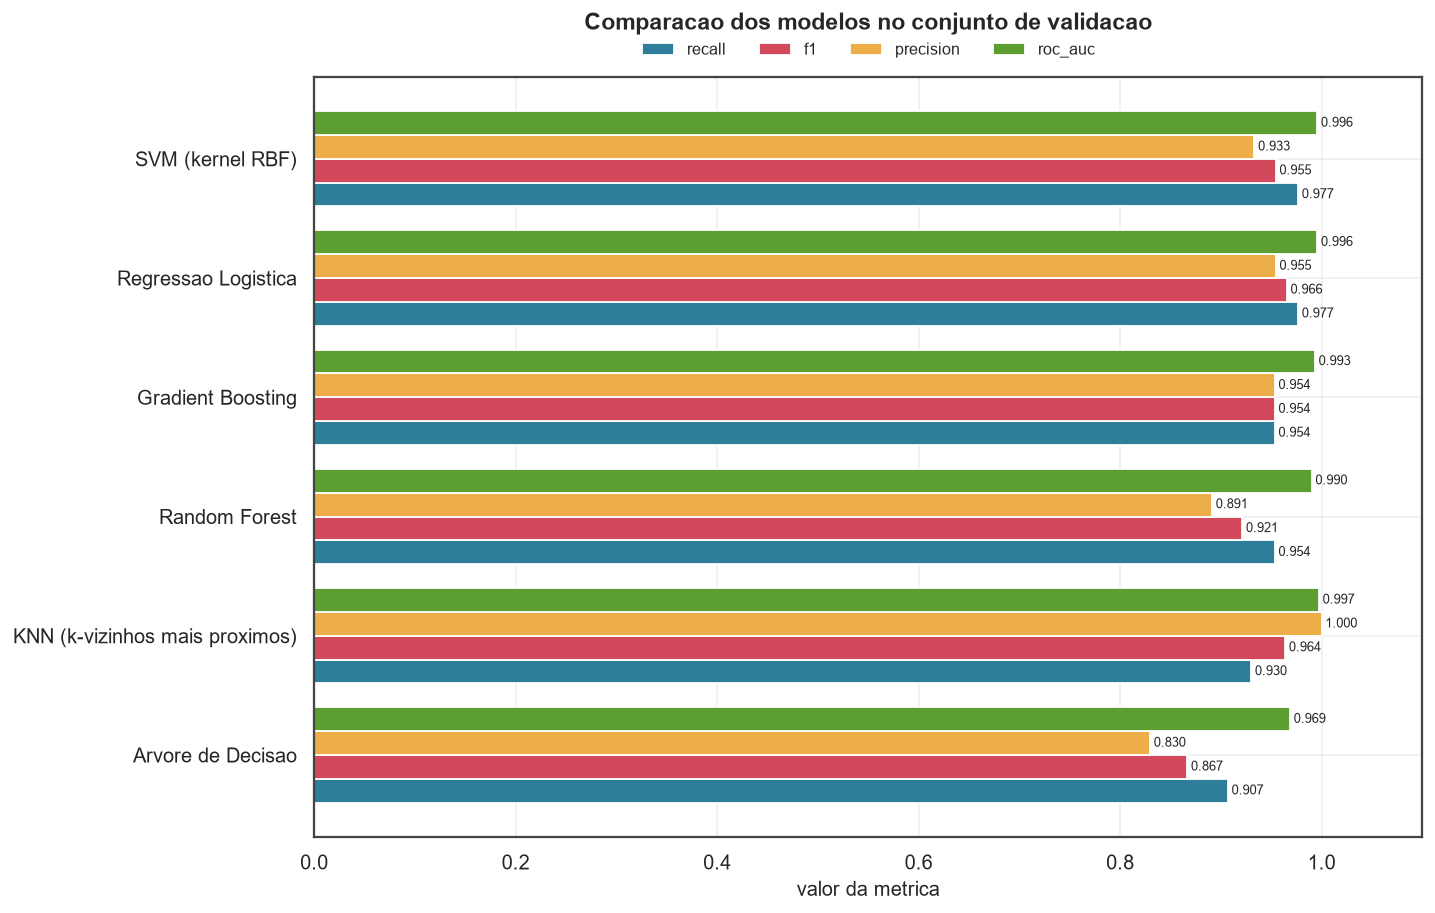

20:49:29 | INFO    | figura salva -> etapa1\reports\figures\10_curvas_roc_pr.png


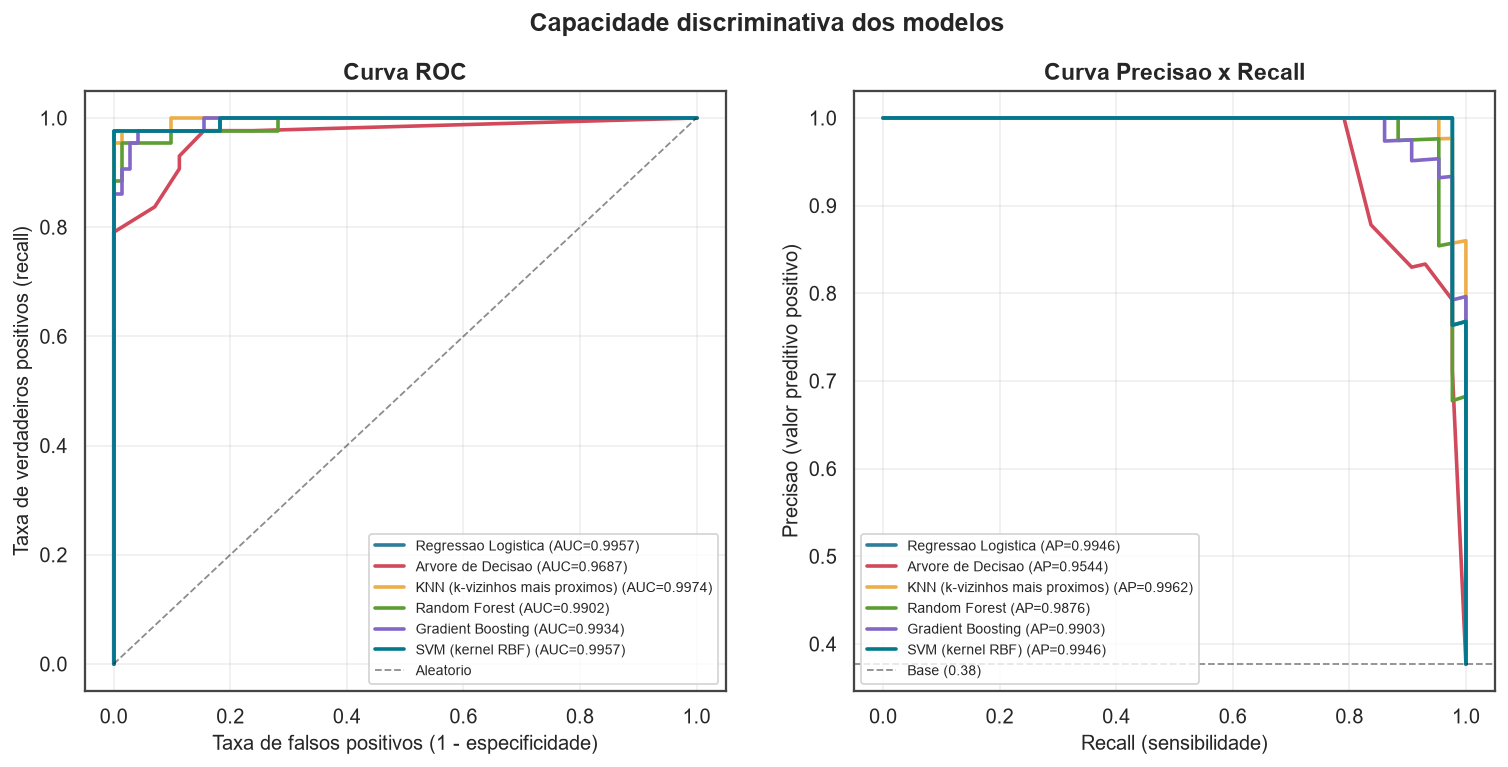

In [22]:
display(Image(evaluate.plot_model_comparison(tabela_val)))
display(Image(evaluate.plot_roc_pr(
    {tm.label: (split.y_val, val_scores[k]) for k, tm in treinados.items()}
)))

## 8. Escolha da metrica e calibracao do limiar

Os dois erros tem custos assimetricos:

- **Falso negativo** (cancer classificado como benigno): o paciente e liberado, o tumor
  evolui e a janela terapeutica se fecha. Custo potencial: a vida.
- **Falso positivo** (benigno marcado como suspeito): gera ansiedade e uma biopsia
  confirmatoria. E caro e desagradavel, mas **reversivel**.

Logo a metrica que governa a operacao e o **recall da classe maligna**, com F1 e
precisao de contrapeso para o sistema nao virar um alarme permanente. O limiar deixa de
ser o 0,50 default e passa a ser um **parametro clinico**: fixamos a sensibilidade
minima aceitavel e, entre todos os limiares que a atendem, ficamos com o mais alto -
o que minimiza biopsias desnecessarias.

20:49:30 | INFO    | limiar calibrado = 0.0934 | recall = 1.0000 | precisao = 0.7679 (meta de recall 0.99)


limiar clinico = 0.0934
  recall  na validacao = 1.0000
  precisao na validacao = 0.7679


20:49:30 | INFO    | figura salva -> etapa1\reports\figures\11_analise_limiar.png


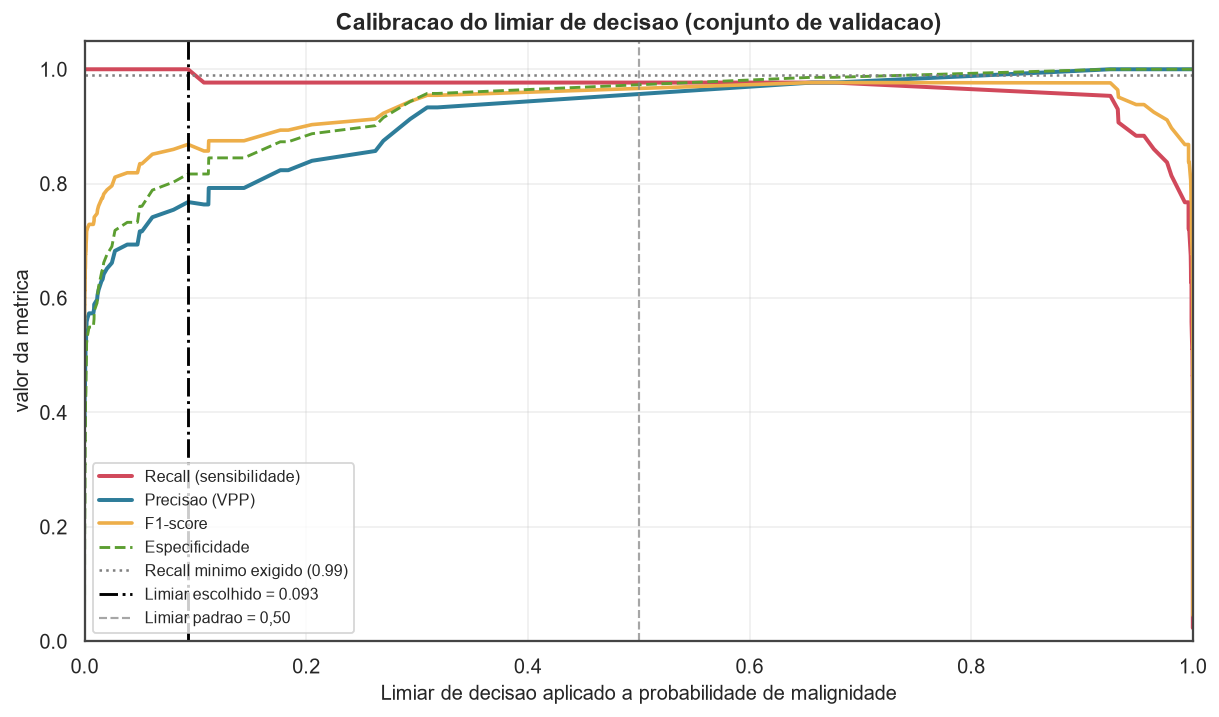

In [23]:
escolha = evaluate.tune_threshold(split.y_val, val_scores[campeao_chave], target_recall=0.99)
print(f"limiar clinico = {escolha.threshold:.4f}")
print(f"  recall  na validacao = {escolha.achieved_recall:.4f}")
print(f"  precisao na validacao = {escolha.achieved_precision:.4f}")
display(Image(evaluate.plot_threshold_analysis(escolha)))

## 9. Avaliacao final no conjunto de teste

O campeao e reajustado em treino + validacao (para aproveitar todos os dados
disponiveis) com os hiperparametros e o limiar **ja congelados** - portanto sem
vazamento - e so entao o teste e aberto, uma unica vez.

In [24]:
pipeline_final = models.build_pipeline(campeao.spec, split.X_trainval)
pipeline_final.set_params(**{f"model__{k}": v for k, v in campeao.best_params.items()})
pipeline_final.fit(split.X_trainval, split.y_trainval)

scores_teste = models.predict_scores(pipeline_final, split.X_test)
evaluate.metrics_table({
    f"{campeao.label} @ limiar padrao 0.50": evaluate.compute_metrics(split.y_test, scores_teste, 0.50),
    f"{campeao.label} @ limiar clinico {escolha.threshold:.3f}":
        evaluate.compute_metrics(split.y_test, scores_teste, escolha.threshold),
})

20:49:30 | INFO    | preprocessador: 30 coluna(s) numerica(s) [escala=standard], 0 categorica(s)


,recall,f1,precision,specificity,accuracy,balanced_accuracy,roc_auc,pr_auc,mcc,brier,threshold,tp,fn,fp,tn
Regressao Logistica @ limiar clinico 0.093,0.9762,0.9111,0.8542,0.9028,0.9298,0.9395,0.996,0.9943,0.8588,0.0211,0.0934,41,1,7,65
Regressao Logistica @ limiar padrao 0.50,0.9524,0.9639,0.9756,0.9861,0.9737,0.9692,0.996,0.9943,0.9433,0.0211,0.5000,40,2,1,71


20:49:31 | INFO    | figura salva -> etapa1\reports\figures\nb_confusao_padrao.png


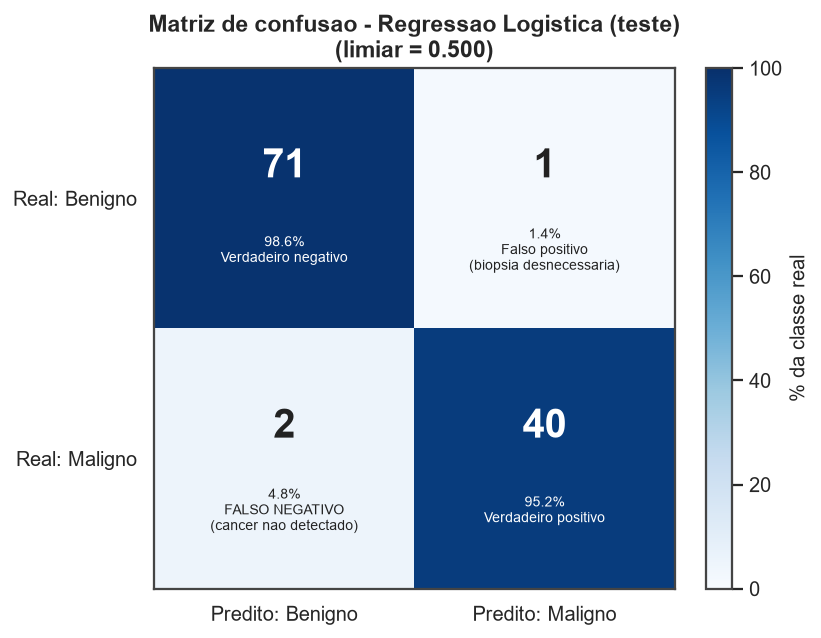

20:49:31 | INFO    | figura salva -> etapa1\reports\figures\nb_confusao_clinica.png


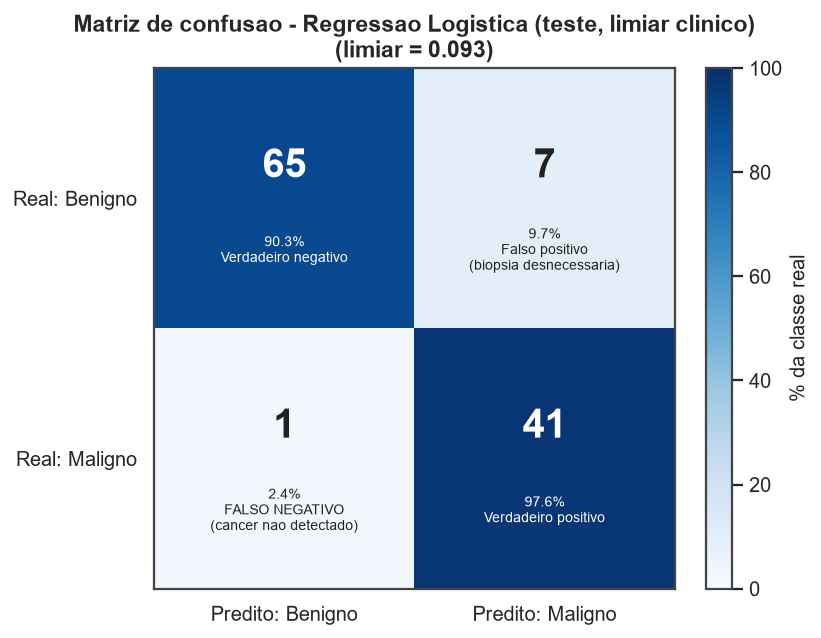

In [25]:
display(Image(evaluate.plot_confusion(split.y_test, scores_teste, 0.50,
        f"Matriz de confusao - {campeao.label} (teste)", "nb_confusao_padrao")))
display(Image(evaluate.plot_confusion(split.y_test, scores_teste, escolha.threshold,
        f"Matriz de confusao - {campeao.label} (teste, limiar clinico)", "nb_confusao_clinica")))

20:49:31 | INFO    | figura salva -> etapa1\reports\figures\14_distribuicao_scores.png


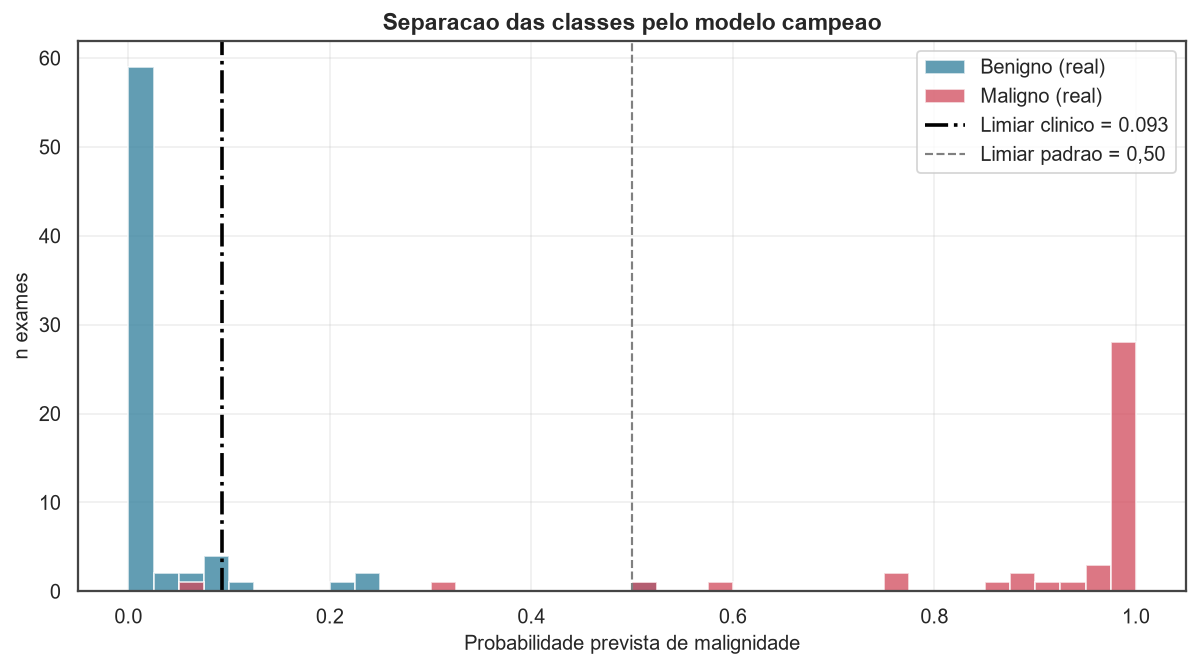

20:49:32 | INFO    | figura salva -> etapa1\reports\figures\15_calibracao.png


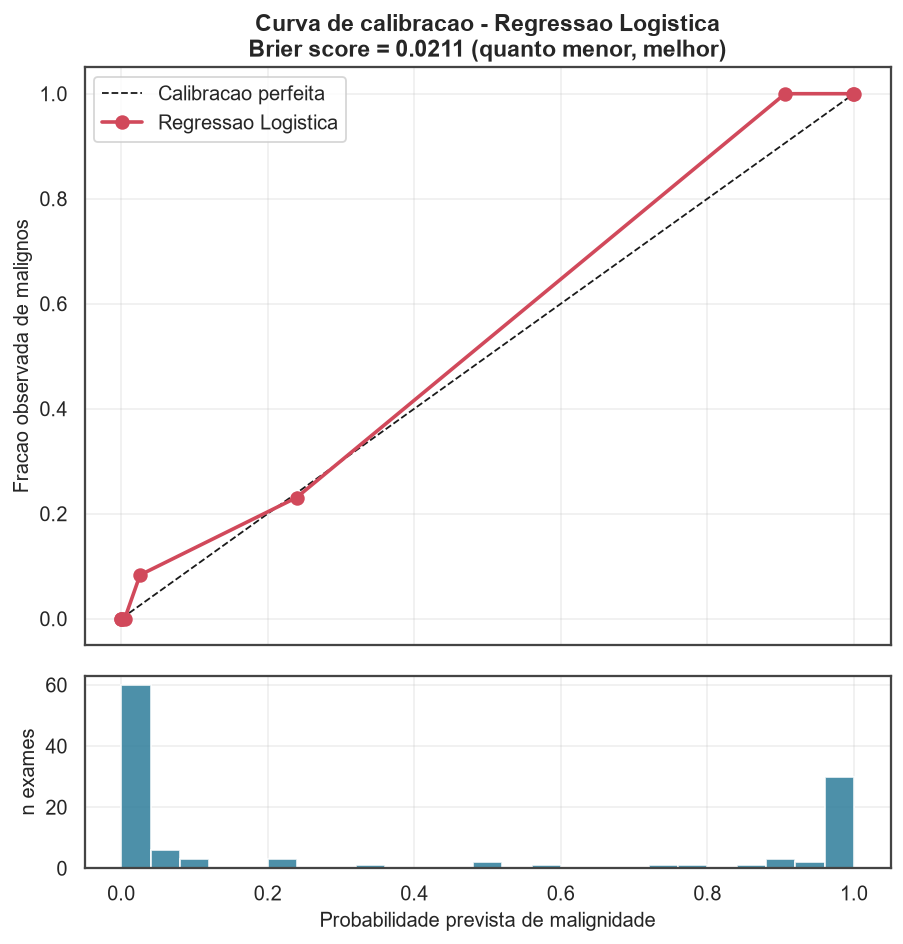

In [26]:
display(Image(evaluate.plot_score_distribution(split.y_test, scores_teste, escolha.threshold)))
display(Image(evaluate.plot_calibration(split.y_test, scores_teste, campeao.label)))

**Leitura.** Baixar o limiar de 0,50 para o valor calibrado troca falsos negativos por
falsos positivos - exatamente a troca que a clinica quer fazer. Cada falso negativo
evitado custa algumas biopsias confirmatorias a mais, e essa e uma decisao **do comite
clinico**, nao do cientista de dados: o codigo apenas expoe o botao.

In [27]:
erros = evaluate.error_analysis(split.X_test, split.y_test, scores_teste,
                                escolha.threshold, top_feats)
print(f"exames classificados incorretamente no teste: {len(erros)}")
erros

exames classificados incorretamente no teste: 8


,indice_original,classe_real,classe_prevista,prob_malignidade,tipo_erro,concave_points_worst,perimeter_worst,concave_points_mean,radius_worst,perimeter_mean
0,455,Benigno,Maligno,0.5113,falso positivo,0.078,96.69,0.033,15.05,86.34
1,456,Benigno,Maligno,0.2372,falso positivo,0.068,86.04,0.020,13.12,74.87
2,208,Benigno,Maligno,0.2276,falso positivo,0.113,99.48,0.051,14.55,87.02
3,560,Benigno,Maligno,0.2026,falso positivo,0.105,100.20,0.043,15.30,91.38
4,448,Benigno,Maligno,0.1164,falso positivo,0.096,108.10,0.029,16.30,94.25
5,347,Benigno,Maligno,0.0967,falso positivo,0.125,114.20,0.035,17.27,94.87
6,128,Benigno,Maligno,0.0944,falso positivo,0.142,105.90,0.085,16.11,99.58
7,73,Maligno,Benigno,0.0635,FALSO NEGATIVO,0.138,110.30,0.051,16.57,90.43


## 10. Interpretabilidade

Um modelo que nao explica a propria decisao nao e adotavel em medicina. Tres lentes
complementares: **importancia por permutacao** (o que o modelo realmente usa),
**SHAP global** (magnitude e direcao) e **SHAP individual** (por que ESTE paciente
foi sinalizado).

20:49:33 | INFO    | figura salva -> etapa1\reports\figures\19_importancia_permutacao.png


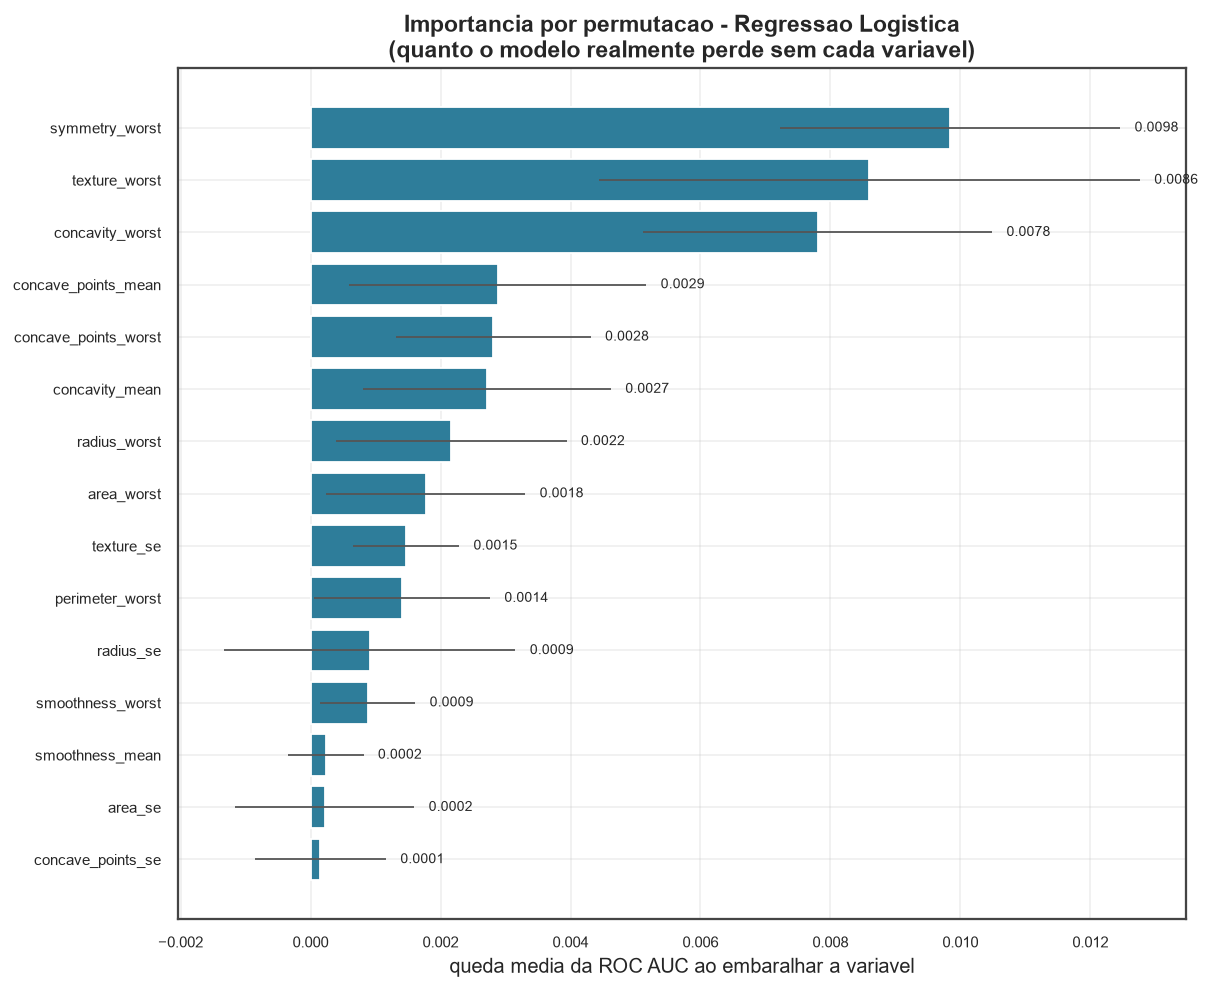

,feature,queda_media,desvio
0,symmetry_worst,0.009838,0.002620
1,texture_worst,0.008598,0.004163
2,concavity_worst,0.007804,0.002683
3,concave_points_mean,0.002877,0.002289
4,concave_points_worst,0.002811,0.001499
5,concavity_mean,0.002712,0.001910
6,radius_worst,0.002166,0.001773
7,area_worst,0.001769,0.001534
8,texture_se,0.001472,0.000813
9,perimeter_worst,0.001405,0.001355


In [28]:
perm = interpret.permutation_report(pipeline_final, split.X_test, split.y_test, n_repeats=20)
display(Image(interpret.plot_permutation_importance(perm, campeao.label)))
perm.head(10)

20:49:45 | INFO    | SHAP calculado para 114 exames x 30 variaveis


20:49:45 | INFO    | figura salva -> etapa1\reports\figures\21_shap_importancia_global.png


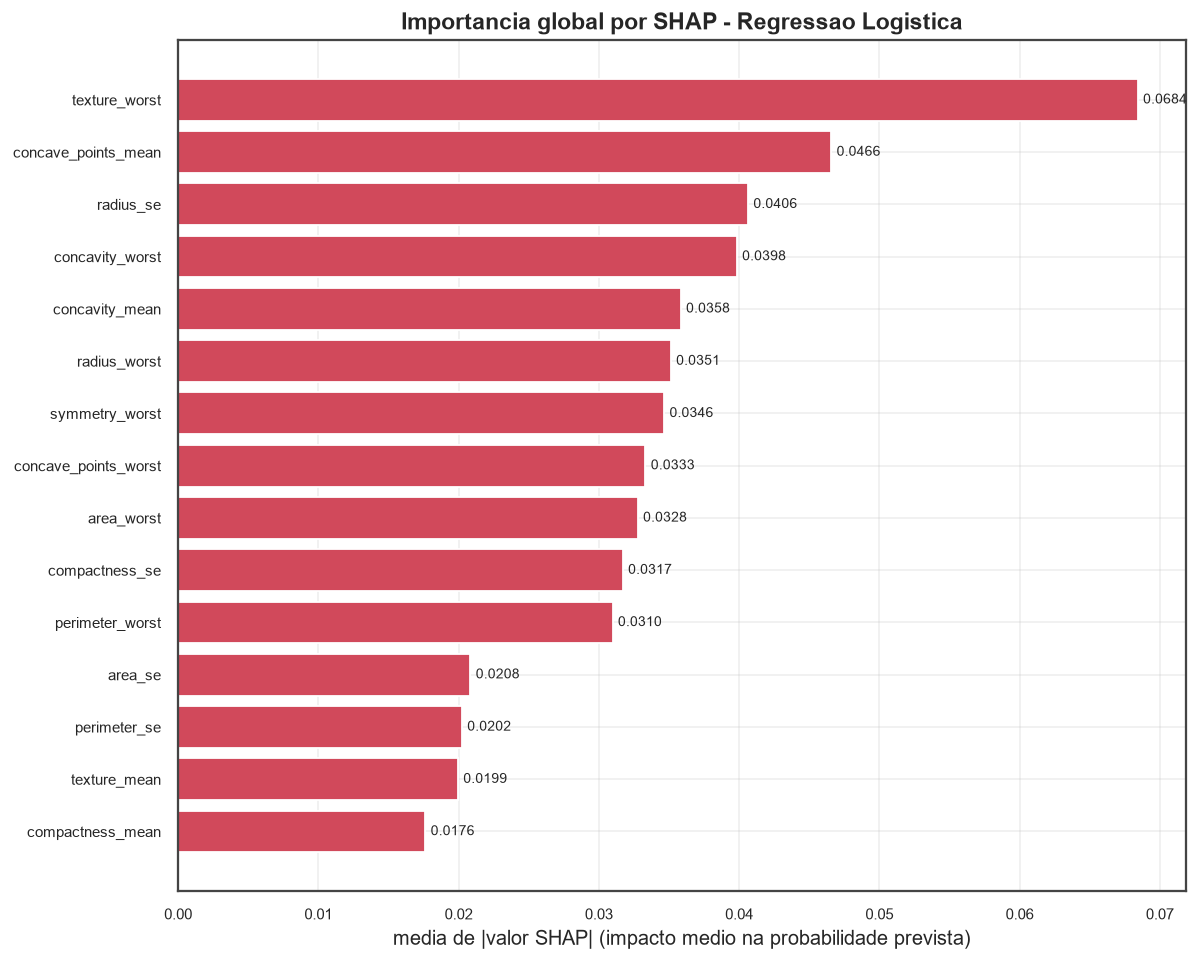

20:49:46 | INFO    | figura salva -> etapa1\reports\figures\20_shap_beeswarm.png


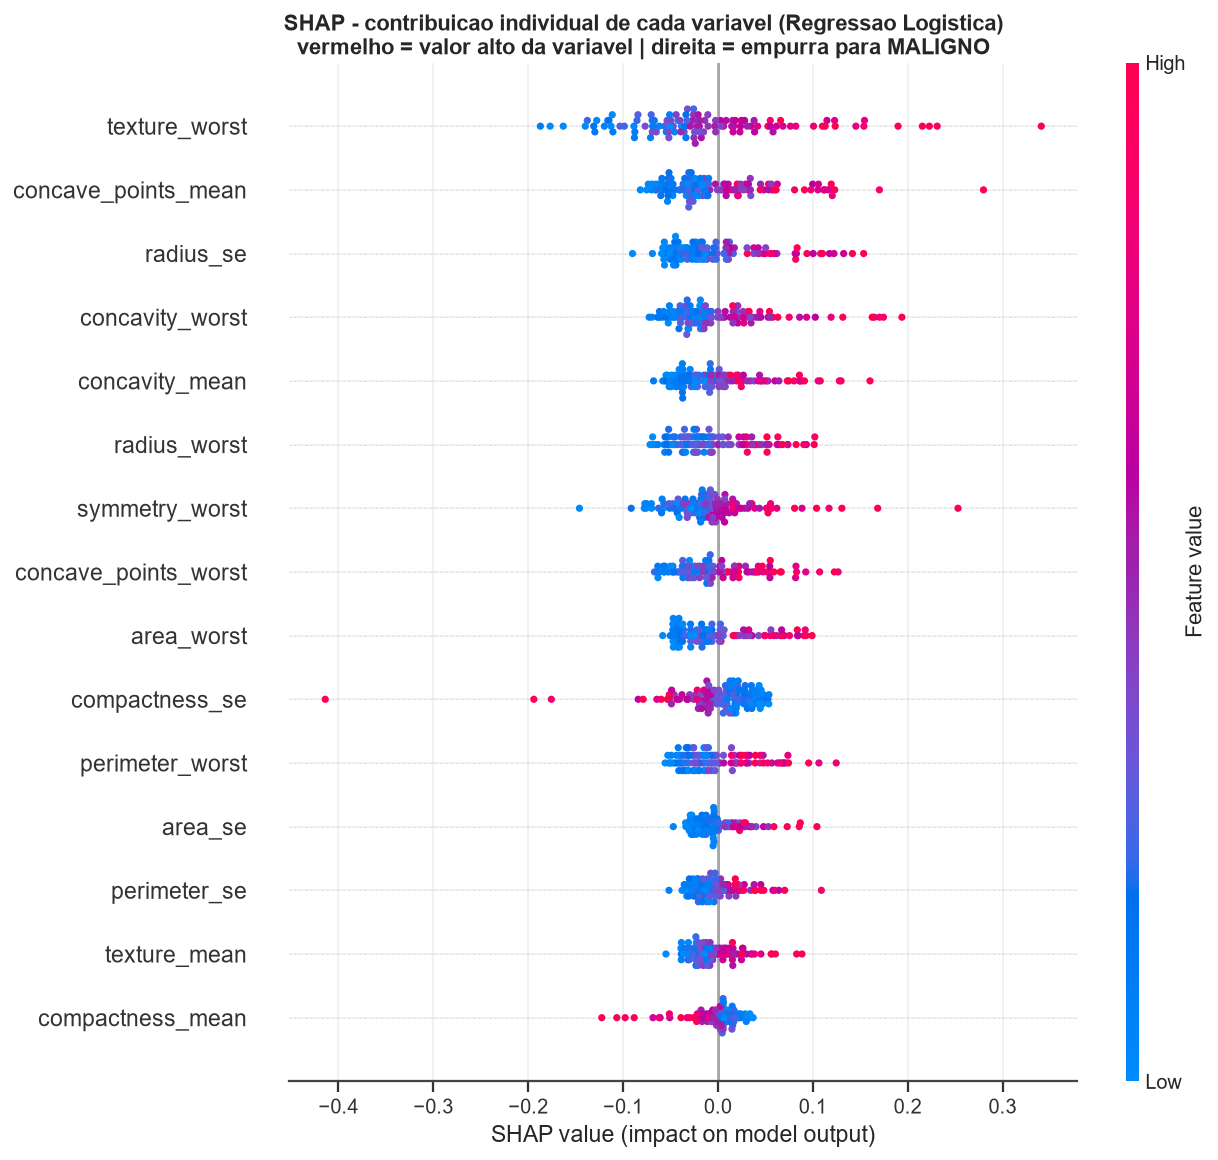

In [29]:
shap_res = interpret.compute_shap(pipeline_final, split.X_trainval, split.X_test,
                                  tree_based=campeao.spec.tree_based)
display(Image(interpret.plot_shap_bar(shap_res, campeao.label)))
display(Image(interpret.plot_shap_summary(shap_res, campeao.label)))

casos selecionados para explicacao individual: {'falso_negativo': 16, 'falso_positivo': 4, 'verdadeiro_positivo': 108, 'caso_ambiguo': 92}


20:49:46 | INFO    | figura salva -> etapa1\reports\figures\nb_shap_falso_negativo.png


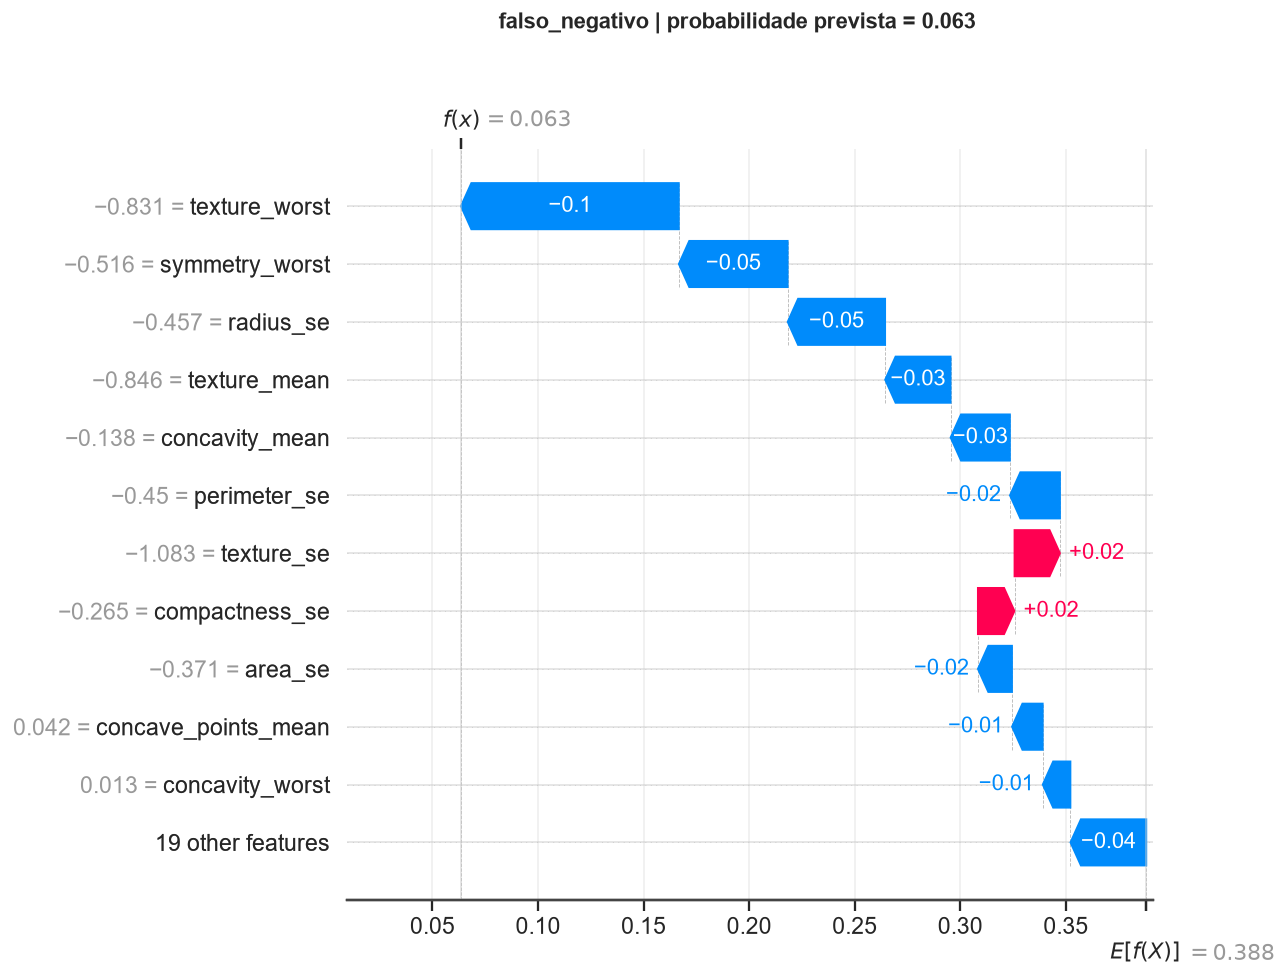

20:49:47 | INFO    | figura salva -> etapa1\reports\figures\nb_shap_falso_positivo.png


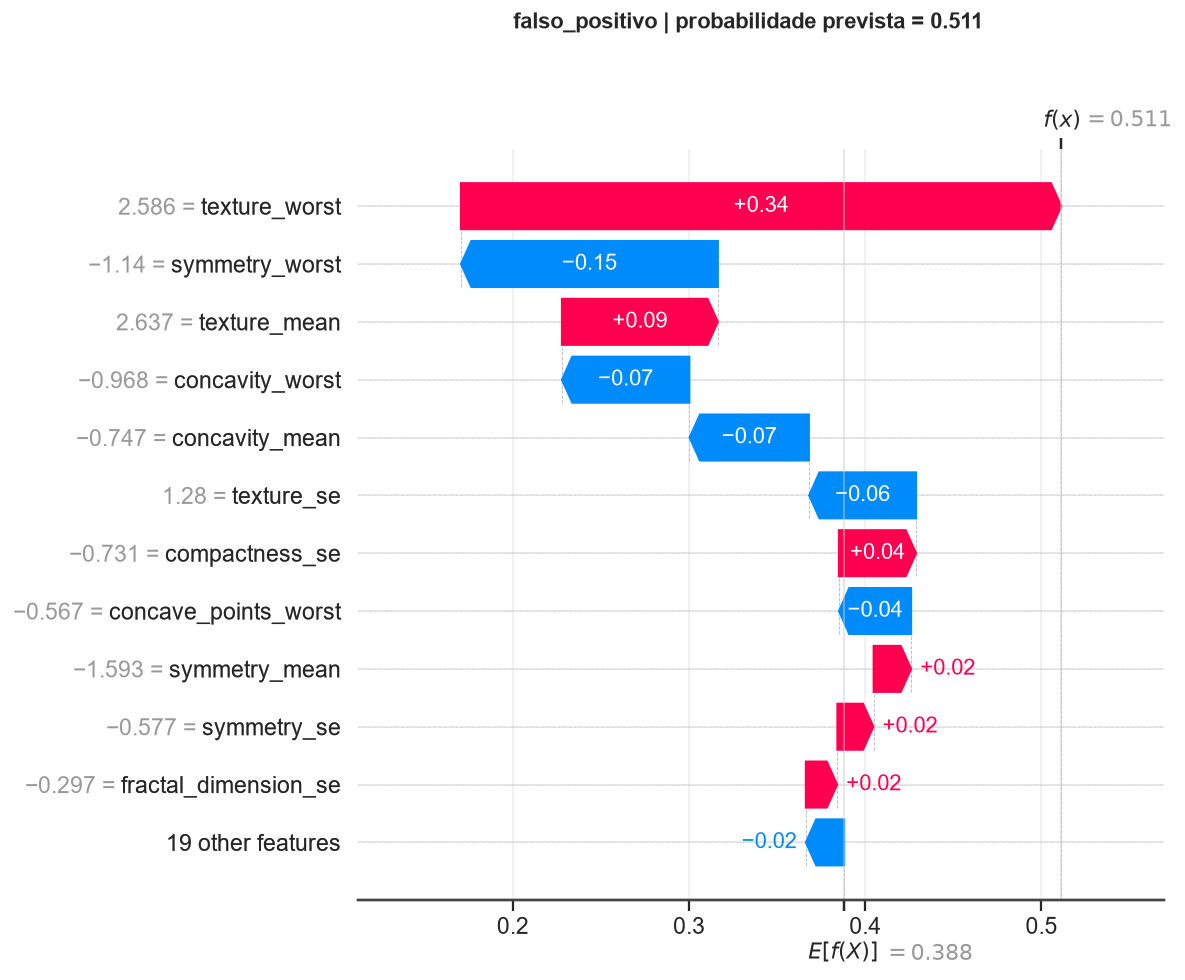

20:49:47 | INFO    | figura salva -> etapa1\reports\figures\nb_shap_verdadeiro_positivo.png


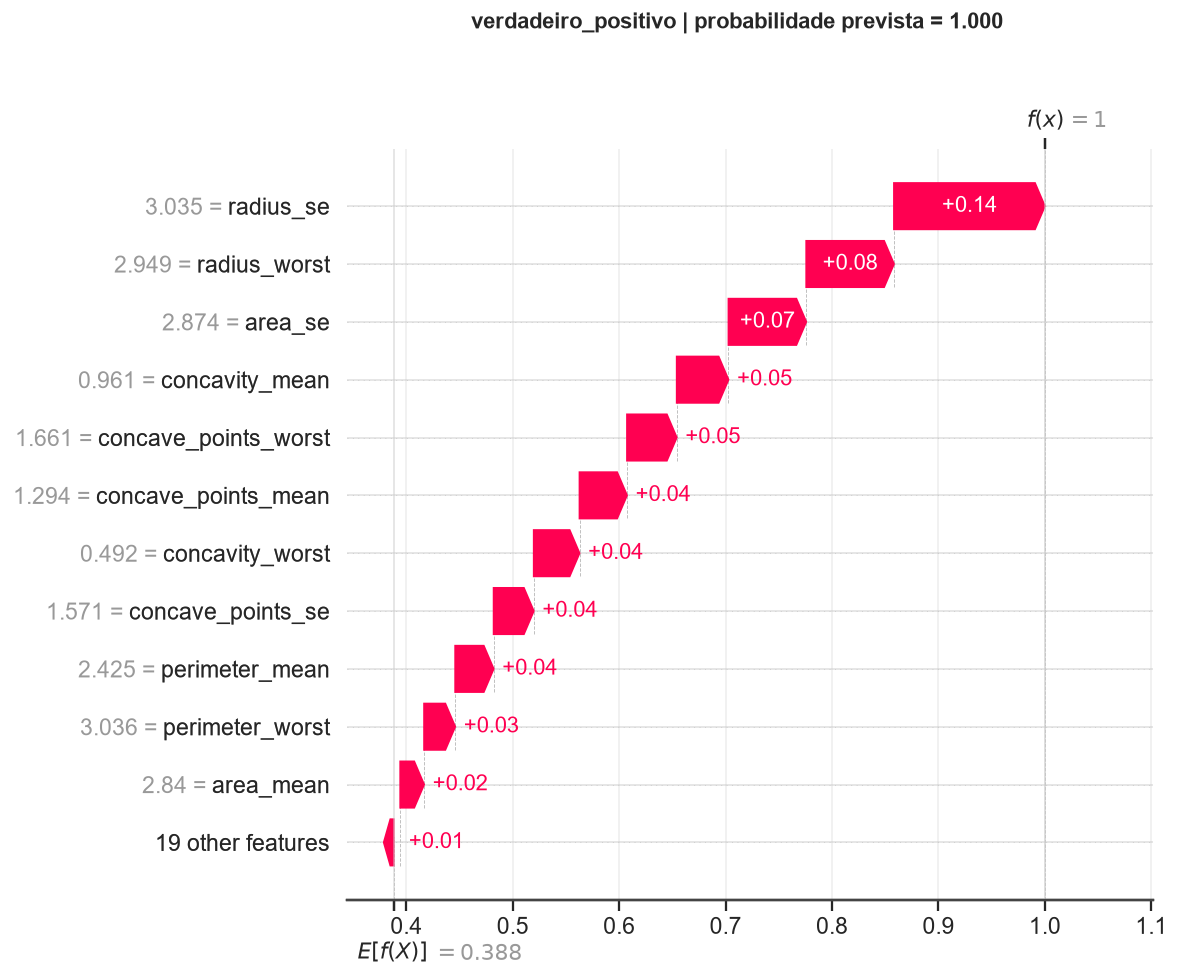

20:49:48 | INFO    | figura salva -> etapa1\reports\figures\nb_shap_caso_ambiguo.png


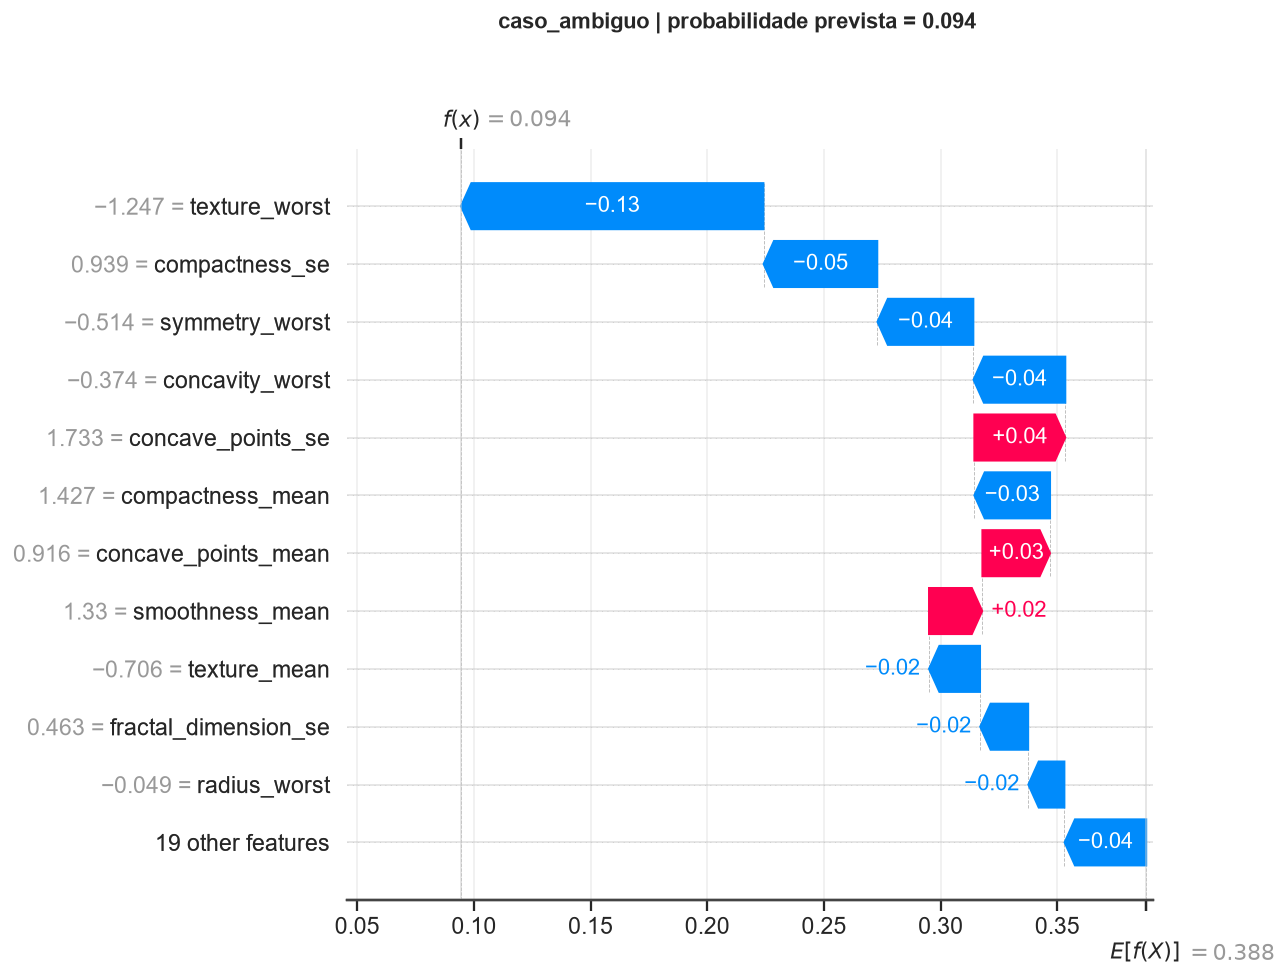

In [30]:
casos = interpret.pick_cases(split.y_test, scores_teste, escolha.threshold)
print("casos selecionados para explicacao individual:", casos)

for nome, pos in casos.items():
    display(Image(interpret.plot_shap_waterfall(
        shap_res, pos,
        f"{nome} | probabilidade prevista = {scores_teste[pos]:.3f}",
        f"nb_shap_{nome}",
    )))

**Leitura.** O grafico em cascata e o que efetivamente entra no laudo de apoio: mostra,
para um paciente especifico, quais medidas empurraram o score para cima e quais o
puxaram para baixo. E isso que permite ao medico **discordar de forma fundamentada** -
por exemplo, ao notar que o modelo se apoiou em uma medida afetada por um artefato de
preparo da lamina.

In [31]:
# Modelo de referencia "caixa de vidro": razoes de chance sao a linguagem clinica.
ref_spec = next(s for s in models.model_catalog() if s.key == "logistic_regression")
ref = models.build_pipeline(ref_spec, split.X_trainval)
ref.set_params(model__C=1.0)
ref.fit(split.X_trainval, split.y_trainval)
interpret.native_importance(ref).head(10)

20:49:48 | INFO    | preprocessador: 30 coluna(s) numerica(s) [escala=standard], 0 categorica(s)


,feature,coeficiente,odds_ratio_por_dp,importancia
0,texture_worst,1.423806,4.152896,1.423806
1,radius_se,1.243632,3.468188,1.243632
2,symmetry_worst,1.059102,2.883780,1.059102
3,concave_points_mean,0.954814,2.598186,0.954814
4,area_se,0.933406,2.543156,0.933406
5,area_worst,0.924092,2.519580,0.924092
6,compactness_se,-0.915840,0.400180,0.915840
7,concavity_worst,0.910627,2.485880,0.910627
8,radius_worst,0.896585,2.451218,0.896585
9,concavity_mean,0.790535,2.204576,0.790535


## 11. Robustez a dados ausentes

O WDBC nao tem valores faltantes, o que deixaria o ramo de imputacao sem exercicio. Um
prontuario hospitalar real, porem, chega incompleto. Injetamos ausencias MCAR para medir
a degradacao.

In [32]:
linhas = []
for frac in (0.0, 0.05, 0.10, 0.20):
    Xm = split.X_test if frac == 0 else inject_missing(split.X_test, frac)
    m = evaluate.compute_metrics(split.y_test, models.predict_scores(pipeline_final, Xm),
                                 escolha.threshold)
    linhas.append({"ausentes": f"{frac:.0%}", "recall": round(m["recall"], 4),
                   "precisao": round(m["precision"], 4), "f1": round(m["f1"], 4),
                   "roc_auc": round(m["roc_auc"], 4), "falsos_negativos": m["fn"]})
pd.DataFrame(linhas).set_index("ausentes")

20:49:48 | INFO    | injetados 168 valores ausentes (4.9% das celulas)


20:49:48 | INFO    | injetados 348 valores ausentes (10.2% das celulas)


20:49:48 | INFO    | injetados 717 valores ausentes (21.0% das celulas)


,recall,precisao,f1,roc_auc,falsos_negativos
ausentes,,,,,
0%,0.9762,0.8542,0.9111,0.9960,1
5%,0.9762,0.8913,0.9318,0.9960,1
10%,0.9762,0.9111,0.9425,0.9950,1
20%,0.9524,0.8696,0.9091,0.9901,2


## 12. Discussao critica - o modelo pode ser usado na pratica?

**Sim, mas com escopo restrito e como apoio, nunca como decisor.**

**Como usar.** Um fluxo de triagem em tres faixas, nao um rotulo binario:

| faixa | criterio | conduta |
|---|---|---|
| VERDE | score abaixo do limiar clinico | segue a fila de rotina |
| AMARELO | entre o limiar e 0,90 | revisao humana prioritaria (zona de incerteza) |
| VERMELHO | score >= 0,90 | encaminhamento imediato ao mastologista |

O ganho nao e "acertar o diagnostico" - e **reordenar a fila** para que os casos graves
sejam vistos primeiro e para que a incerteza seja explicitada em vez de escondida atras
de um rotulo.

**Limitacoes honestas.**

1. **Amostra pequena e de uma unica fonte.** 569 biopsias de um unico centro (Wisconsin,
   anos 1990). Um intervalo de confianca sobre 114 exames de teste e largo; qualquer
   metrica aqui precisa ser revalidada prospectivamente na populacao do hospital.
2. **As variaveis nao caem do ceu.** As 30 medidas pressupoem segmentacao digital do
   nucleo celular a partir da lamina. Sem essa etapa padronizada e calibrada, o modelo
   nao tem entrada valida - e desvio de calibracao entre equipamentos degrada o
   desempenho silenciosamente.
3. **Ausencia de dados demograficos.** Nao ha idade, etnia ou historico familiar, entao
   nao e possivel auditar o modelo por subgrupo. Sem essa auditoria nao se pode afirmar
   que ele e igualmente seguro para todas as pacientes.
4. **Deslocamento de distribuicao.** Novo microscopio, novo protocolo de coloracao ou
   nova equipe mudam a distribuicao das medidas. Exige monitoramento continuo do score e
   das taxas de alarme.

**Requisitos para uma implantacao responsavel:** validacao prospectiva local; limiar
homologado pelo comite clinico (e nao pelo time de dados); registro auditavel de toda
predicao com sua explicacao SHAP; monitoramento de deriva; e um botao explicito de
discordancia para o medico, cujo uso realimenta o proximo ciclo de treino.

> **O modelo prioriza. O medico diagnostica.**